# **Imports**

In [5]:
from earthscape.constants import SG_MAPPING, SG_COLORS

import os
import yaml
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import pearsonr, spearmanr, kendalltau
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# **Setup**

In [2]:
###################################
# Define Parameters & Settings
###################################

# output directory for deliverables...
output_dir = os.path.join(r'../assets/sgmap-net/classification')
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)

# directory for experiments...
exp_dir = r'../experiments/sgmap-net/classification'

# **Loss Ablation**

## *Class Balance Strategies*

In [7]:
#############################################
# Class Balance Schemes for Loss Ablation
#############################################

# path to imbalance metrics
stats_path = r'../assets/data_eda/esv1p1_imbalance_metrics.csv'

# read into df
stats = pd.read_csv(stats_path)


##### inverse class frequency - PyTorch implementation for BCE pos_weight - (N-n_c) / n_c
N = len(glob.glob(r'../data/**/patches/*mask.tif'))
n_c = stats['Frequency (n)']
icf = (N-n_c) / n_c


##### IRLbl - just IRLbl
irlbl = stats['IRLbl']


##### ENS - Cui et al. (1/ENS)
raw_w_c = 1 / stats['N_eff']
sum_w_c = raw_w_c.sum()
normalize_factor = 7 / sum_w_c
final_w_c = raw_w_c * normalize_factor

print('ICF (PyTorch method)')
print([str(x) for x in icf])

print('\nIRLbl')
print([str(x) for x in irlbl])

print('\nENS (Cui et al)')
print([str(x) for x in final_w_c])

ICF (PyTorch method)
['0.06064022411260292', '0.6512073183703861', '1.254938988959907', '1.8461679501283461', '3.0498304200365247', '20.634843205574914', '113.98518518518519']

IRLbl
['1.0', '1.556802467822572', '2.126016850668216', '2.6834433443344334', '3.8182885468301593', '20.397909407665505', '108.41111111111113']

ENS (Cui et al)
['0.14232589507165896', '0.15895262573139396', '0.18017563630429495', '0.20284761686636085', '0.2515841609011287', '1.007627921820518', '5.056486143304645']


## *Loss Ablation Results*

In [ ]:


loss_dir = r'../experiments/sgmap-net/classification/loss'


exp_dirs = glob.glob(f"{loss_dir}/**/*", recursive=False)

ablations = []
for d in exp_dirs:
    loss_name = os.path.dirname(d).split(os.sep)[-1]
    input_name = d.split(os.sep)[-1].split('_')[1]
    config_path = os.path.join(d, "config.yml")
    id_path = os.path.join(d, "id_global.csv")
    cd_path = os.path.join(d, "cd_global.csv")

    pos_weight = pd.NA
    if 'pos_weight' in loss_name:
        pos_weight = loss_name.split('-')[1]

    gamma = pd.NA
    alpha = pd.NA
    with open(config_path, "r") as f:
        c = yaml.safe_load(f)
        if 'gamma' in d or 'alpha' in d:
            gamma = c['loss']['classification']['params']['gamma']
            if 'gamma_' in d:
                pos_weight = loss_name.split('_')[1]
        if 'alpha' in d:
            alpha = c['loss']['classification']['params']['alpha']

    id = pd.read_csv(id_path)['macro_f1'].item()
    cd = pd.read_csv(cd_path)['macro_f1'].item()

    df = pd.DataFrame(
        columns=['input', 'pos_weight', 'gamma', 'alpha', 'f1_id', 'f1_cd'], 
        data=[[input_name, pos_weight, gamma, alpha, id, cd]]
        )
    ablations.append(df)

df = pd.concat(ablations)
df['delta'] = df['f1_id'] - df['f1_cd']
df['delta_rel'] = df['delta'] / df['f1_id'] * 100
df['total'] = df['f1_id'] + df['f1_cd']
df.fillna('-', inplace=True)
df.sort_values(['input', 'total'], ascending=[True, False], inplace=True)
output_path = os.path.join(output_dir, 'loss_ablation.csv')
df.to_csv(output_path, index=False)


df.groupby(['pos_weight', 'gamma', 'alpha'])['total'].mean().sort_values(ascending=False)

# **Pre-trained vs. Random Initialization**

In [85]:

random_init_paths = glob.glob(r'../experiments/sgmap-net/classification/random_init/*')

ablations = []
for d in random_init_paths:
    input_name = os.path.split(d)[-1].split('_')[1]
    config_path = os.path.join(d, 'config.yml')
    id_path = os.path.join(d, 'id_global.csv')
    cd_path = os.path.join(d, 'cd_global.csv')

    with open(config_path, "r") as f:
        c = yaml.safe_load(f)
        pt = c['model']['sgmapnet_params']['pretrained']

    id = pd.read_csv(id_path)['macro_f1'].item()
    cd = pd.read_csv(cd_path)['macro_f1'].item()

    df = pd.DataFrame(columns=['input', 'pretrained', 'f1_id', 'f1_cd'], data=[[input_name, pt, id, cd]])
    ablations.append(df)

df = pd.concat(ablations)
df['delta'] = df['f1_id'] - df['f1_cd']
df['delta_rel'] = df['delta'] / df['f1_id'] * 100
df['total'] = df['f1_id'] + df['f1_cd']
df.sort_values(['input', 'total'], ascending=[True, False], inplace=True)
output_path = os.path.join(output_dir, 'pretrain_ablation.csv')
df.to_csv(output_path, index=False)
df

,input,pretrained,f1_id,f1_cd,delta,delta_rel,total
0,dem,True,0.659143,0.516193,0.142950,21.687257,1.175335
0,dem,False,0.650695,0.478100,0.172595,26.524698,1.128795
0,dem+s-ms,True,0.660962,0.601564,0.059398,8.986570,1.262527
0,dem+s-ms,False,0.662831,0.541501,0.121329,18.304710,1.204332
0,s-5,True,0.632307,0.601038,0.031269,4.945165,1.233345
0,s-5,False,0.646918,0.578546,0.068371,10.568794,1.225464
0,s-ms,True,0.644994,0.614055,0.030939,4.796722,1.259049
0,s-ms,False,0.643869,0.583712,0.060156,9.342959,1.227581


# **Variance**

## *Within-seed Peformance*

In [101]:

var_dirs = glob.glob(r'../experiments/sgmap-net/classification/variance/*')

experiments = []
for d in var_dirs:

    inputs = os.path.basename(d).split('_')[1:-2]
    if len(inputs) > 1:
        modalities = [x.split('-')[0] for x in inputs]
        if len(set(modalities)) == 1:
            inputs = [modalities[0] + '-ms']
    inputs = '+'.join(inputs)

    with open(os.path.join(d, 'config.yml'), 'r') as f:
        cfg = yaml.safe_load(f)
    seed = cfg['experiment']['seed']
    encoder = cfg['model']['encoder_name']
    fusion = cfg['model']['sgmapnet_params']['embedding_fusion']
    if (fusion == 'none') and ('ms' in inputs):
        fusion = 'stacking'
    id = pd.read_csv(os.path.join(d, 'id_global.csv'))
    cd = pd.read_csv(os.path.join(d, 'cd_global.csv'))

    df = pd.DataFrame()
    df.loc[0, 'seed'] = seed
    df['seed'] = df['seed'].astype(int)
    df.loc[0, 'encoder'] = encoder
    df.loc[0, 'input'] = inputs
    df.loc[0, 'fusion'] = fusion
    df = df.merge(right=id, how='left', left_index=True, right_index=True)
    df = df.merge(right=cd, how='left', left_index=True, right_index=True, suffixes=['', '_cd'])
    experiments.append(df)

df = pd.concat(experiments, ignore_index=True)
df.sort_values(['input', 'encoder', 'fusion', 'seed'], ascending=[True, True, False, True], inplace=True)
df.to_csv(r'../assets/sgmap-net/classification/variance.csv', index=False)
df.head(8)

,seed,encoder,input,fusion,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd
0,42,resnext50_32x4d,dem,none,0.688421,0.696601,0.679624,0.909185,0.732415,0.885603,0.517866,0.606695,0.542988,0.772076,0.596812,0.858631
1,90,resnext50_32x4d,dem,none,0.669951,0.714795,0.679720,0.911376,0.734039,0.883929,0.524023,0.601050,0.530238,0.763779,0.582809,0.850632
3,128,resnext50_32x4d,dem,none,0.653156,0.721101,0.681098,0.908252,0.740455,0.883557,0.532686,0.604237,0.555370,0.772622,0.581871,0.854353
2,256,resnext50_32x4d,dem,none,0.684231,0.692126,0.679943,0.907684,0.741799,0.886812,0.481046,0.533360,0.492038,0.744626,0.551283,0.846540
4,42,vit_b_16,dem,none,0.601182,0.691238,0.636324,0.895595,0.698145,0.869885,0.456990,0.677449,0.535549,0.746685,0.589505,0.809896
5,90,vit_b_16,dem,none,0.629828,0.743850,0.658531,0.898375,0.698280,0.867839,0.459850,0.635056,0.525730,0.736542,0.557284,0.823568
7,128,vit_b_16,dem,none,0.635537,0.723293,0.660175,0.893024,0.686996,0.871094,0.457376,0.626866,0.520548,0.758468,0.557562,0.825242
6,256,vit_b_16,dem,none,0.610677,0.692098,0.646074,0.901411,0.701276,0.872954,0.458876,0.658273,0.520722,0.698751,0.543999,0.795759


## *Across-split Performance*

In [3]:
var_dirs = glob.glob(r'../experiments/sgmap-net/classification/variance_splits/*')

experiments = []
for d in var_dirs:

    inputs = os.path.basename(d).split('_')[1:-2]
    if len(inputs) > 1:
        modalities = [x.split('-')[0] for x in inputs]
        if len(set(modalities)) == 1:
            inputs = [modalities[0] + '-ms']
    inputs = '+'.join(inputs)

    with open(os.path.join(d, 'config.yml'), 'r') as f:
        cfg = yaml.safe_load(f)
    split = cfg['splits']['root'].split('/')[1]
    encoder = cfg['model']['encoder_name']
    fusion = cfg['model']['sgmapnet_params']['embedding_fusion']
    if (fusion == 'none') and ('ms' in inputs):
        fusion = 'stacking'
    id = pd.read_csv(os.path.join(d, 'id_global.csv'))
    cd = pd.read_csv(os.path.join(d, 'cd_global.csv'))

    df = pd.DataFrame()
    df.loc[0, 'split'] = split
    df.loc[0, 'encoder'] = encoder
    df.loc[0, 'input'] = inputs
    df.loc[0, 'fusion'] = fusion
    df = df.merge(right=id, how='left', left_index=True, right_index=True)
    df = df.merge(right=cd, how='left', left_index=True, right_index=True, suffixes=['', '_cd'])
    experiments.append(df)

df = pd.concat(experiments, ignore_index=True)
df.sort_values(['encoder', 'input', 'fusion'], ascending=[True, False, False], inplace=True)
df.to_csv(r'../assets/sgmap-net/classification/variance_splits.csv', index=False)
df.head(8)

,split,encoder,input,fusion,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd
46,split_seed_42,resnext50_32x4d,s-10,none,0.633977,0.703177,0.655824,0.879000,0.683806,0.870443,0.535552,0.656469,0.585196,0.824696,0.609250,0.853795
47,split_seed_90,resnext50_32x4d,s-10,none,0.642799,0.721899,0.659824,0.889508,0.707840,0.874814,0.553760,0.642192,0.590402,0.795580,0.622274,0.872768
48,split_seed_128,resnext50_32x4d,s-10,none,0.627329,0.763445,0.668016,0.883744,0.713546,0.869606,0.553213,0.701459,0.614528,0.803684,0.640531,0.855841
49,split_seed_256,resnext50_32x4d,s-10,none,0.626192,0.718359,0.657029,0.883530,0.697983,0.873233,0.553870,0.676233,0.599282,0.800203,0.616688,0.859468
30,split_seed_42,resnext50_32x4d,prc-ms+s-ms,stacking,0.667842,0.681104,0.670584,0.897231,0.702602,0.889044,0.569470,0.680646,0.615391,0.849531,0.648778,0.867839
31,split_seed_90,resnext50_32x4d,prc-ms+s-ms,stacking,0.636569,0.788423,0.665720,0.904795,0.717603,0.869792,0.531441,0.762969,0.597778,0.839540,0.662920,0.842913
32,split_seed_128,resnext50_32x4d,prc-ms+s-ms,stacking,0.658001,0.733203,0.681343,0.892583,0.723961,0.885603,0.551476,0.698592,0.607394,0.815426,0.642087,0.866257
33,split_seed_256,resnext50_32x4d,prc-ms+s-ms,stacking,0.639956,0.750736,0.671693,0.894315,0.707986,0.875372,0.552139,0.751117,0.619655,0.847999,0.661512,0.862816


# **Single Feature Experiments**

## *Experiments Compilation*

### Global

In [ ]:
dirs = glob.glob(r'../experiments/sgmap-net/classification/single/*')

dfs = []
for d in dirs:
    config_path = os.path.join(d, 'config.yml')
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    encoder = config['model']['encoder_name']
    exp_type = os.path.split(os.path.dirname(d))[1]
    input = list(config['data']['input'].keys())
    input = '+'.join(input)
    df = pd.DataFrame({'encoder': encoder, 'exp_type': exp_type, 'input': input}, index=[0])

    id_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_path)
    cd_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_path)
    id_cd = pd.merge(left=id, right=cd, how='inner', left_index=True, right_index=True, suffixes=['', '_cd'])
    df = df.merge(id_cd, how='inner', left_index=True, right_index=True)
    dfs.append(df)

df = pd.concat(dfs)
output_path = r'../assets/sgmap-net/classification/single_global.csv'
df.to_csv(output_path, index=False)

df['total'] = df['macro_f1'] + df['macro_f1_cd']
df.sort_values('total', ascending=False).head(10)

,encoder,exp_type,input,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd,total
0,resnext50_32x4d,single,s-10,0.667051,0.698330,0.674017,0.888170,0.715918,0.877511,0.535962,0.695868,0.598633,0.765624,0.651179,0.860677,1.272649
0,vit_b_16,single,s-5,0.590426,0.766289,0.646254,0.867478,0.672634,0.855004,0.527376,0.743626,0.610514,0.815391,0.629369,0.844587,1.256768
0,resnext50_32x4d,single,s-5,0.643111,0.689120,0.655159,0.875486,0.690786,0.880394,0.549497,0.698659,0.598273,0.809109,0.635838,0.859840,1.253432
0,resnext50_32x4d,single,prc-10,0.629832,0.656389,0.638404,0.860314,0.681309,0.872303,0.540929,0.673528,0.591678,0.797460,0.622462,0.857329,1.230082
0,resnext50_32x4d,single,prc-5,0.606390,0.701757,0.642951,0.861835,0.684932,0.862444,0.503633,0.746365,0.586688,0.824507,0.624696,0.824777,1.229639
0,vit_b_16,single,s-10,0.622496,0.694036,0.648676,0.866693,0.682886,0.866908,0.510926,0.662048,0.572299,0.791345,0.583571,0.845889,1.220975
0,resnext50_32x4d,single,sds-5,0.591737,0.684543,0.631687,0.863751,0.680951,0.860677,0.504538,0.714486,0.585830,0.834667,0.604108,0.842076,1.217517
0,vit_b_16,single,s-50,0.592847,0.760668,0.651057,0.844255,0.671581,0.828032,0.502797,0.669528,0.555802,0.777095,0.561152,0.801711,1.206859
0,resnext50_32x4d,single,sds-51,0.598969,0.698800,0.625748,0.870738,0.663928,0.850074,0.514397,0.687403,0.576266,0.796179,0.593107,0.839007,1.202015
0,vit_b_16,single,s-20,0.590914,0.722420,0.641194,0.868027,0.686054,0.856399,0.497520,0.663952,0.560420,0.766226,0.568264,0.825521,1.201614


### Class-wise

In [3]:
class_dirs = glob.glob(r'../experiments/sgmap-net/classification/single*/*')

f1 = []
auroc = []
for idx, d in enumerate(class_dirs):
    config_path = os.path.join(d, 'config.yml')
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    encoder = config['model']['encoder_name']
    exp_type = os.path.split(os.path.dirname(d))[1]
    input = list(config['data']['input'].keys())
    input = '+'.join(input)
    meta = pd.DataFrame({'encoder': encoder, 'exp_type': exp_type, 'input': input}, index=[0])

    id = pd.read_csv(os.path.join(d, 'id_class.csv')).set_index('class')
    cd = pd.read_csv(os.path.join(d, 'cd_class.csv')).set_index('class')

    id_cd_f1 = pd.concat([id['f1'], cd['f1'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_f1 = pd.merge(left=meta, right=id_cd_f1, left_index=True, right_index=True)
    f1.append(df_f1)

    id_cd_auroc = pd.concat([id['auroc'], cd['auroc'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_auroc = pd.merge(left=meta, right=id_cd_auroc, left_index=True, right_index=True)
    auroc.append(df_auroc)

df_f1 = pd.concat(f1)
df_f1.sort_values(['input', 'encoder'], ascending=True, inplace=True)
df_f1.to_csv(r'../assets/sgmap-net/classification/single_class_f1.csv', index=False)

df_auroc = pd.concat(auroc)
df_auroc.sort_values(['input', 'encoder'], ascending=True, inplace=True)
df_auroc.to_csv(r'../assets/sgmap-net/classification/single_class_auroc.csv', index=False)

df_f1[df_f1['exp_type']=='single'].sort_values('Qaf_cd', ascending=False).head(10)

,encoder,exp_type,input,af1,Qal,Qaf,Qat,Qc,Qca,Qr,af1_cd,Qal_cd,Qaf_cd,Qat_cd,Qc_cd,Qca_cd,Qr_cd
0,vit_b_16,single,plc-100,0.544390,0.774139,0.054054,0.275362,0.681597,0.613358,0.963090,0.442406,0.707957,0.125000,0.053097,0.453350,0.275556,0.987475
0,vit_b_16,single,plc-10,0.618934,0.781382,0.105263,0.254237,0.806042,0.715190,0.964794,0.494343,0.695804,0.121212,0.220183,0.521314,0.584235,0.991795
0,resnext50_32x4d,single,plc-10,0.630470,0.783414,0.074074,0.315152,0.797444,0.708375,0.963088,0.562271,0.705782,0.114286,0.339181,0.500367,0.540311,0.991795
0,resnext50_32x4d,single,ep-101,0.731070,0.814532,0.074074,0.298507,0.849127,0.746961,0.964485,0.720358,0.676722,0.105263,0.326733,0.341026,0.176000,0.989467
0,vit_b_16,single,plc-200,0.540257,0.765172,0.000000,0.260504,0.655679,0.452763,0.963766,0.442062,0.705722,0.100000,0.134387,0.457671,0.253438,0.989141
0,resnext50_32x4d,single,ep-201,0.712664,0.808489,0.070588,0.305677,0.836950,0.768485,0.969863,0.706837,0.728993,0.071429,0.285714,0.469222,0.344633,0.991795
0,resnext50_32x4d,single,sds-21,0.695652,0.773601,0.027027,0.173228,0.864699,0.697727,0.964762,0.645774,0.715275,0.047619,0.284360,0.730107,0.585621,0.987801
0,resnext50_32x4d,single,plc-100,0.544439,0.780488,0.078431,0.270000,0.690110,0.611057,0.960221,0.439386,0.698556,0.047619,0.186047,0.462304,0.328076,0.986428
0,resnext50_32x4d,single,prc-100,0.577166,0.788505,0.073620,0.365385,0.874442,0.781362,0.971079,0.453363,0.710683,0.046512,0.118644,0.789179,0.696113,0.991464
0,resnext50_32x4d,single,plc-200,0.532448,0.765558,0.032086,0.230137,0.655867,0.480972,0.965308,0.425121,0.706874,0.024242,0.145946,0.456511,0.259716,0.991795


## *Comparison*

In [12]:

single_path = r'../assets/sgmap-net/classification/single_compiled.csv'

df_single = pd.read_csv(single_path)

id = df_single[['input', 'exp_type', 'macro_f1']].pivot(columns='exp_type', index='input', values='macro_f1')
id.rename(columns={'single': 'f1_id', 'single_sa': 'f1_id_sa'}, inplace=True)
id['delta_id'] = id['f1_id'] - id['f1_id_sa']
id['delta_rel_id'] = id['delta_id'] / id['f1_id'] * 100

cd = df_single[['input', 'exp_type', 'macro_f1_cd']].pivot(columns='exp_type', index='input', values='macro_f1_cd')
cd.rename(columns={'single': 'f1_cd', 'single_sa': 'f1_cd_sa'}, inplace=True)
cd['delta_cd'] = cd['f1_cd'] - cd['f1_cd_sa']
cd['delta_rel_cd'] = cd['delta_cd'] / cd['f1_cd'] * 100

df = pd.merge(left=id, right=cd, how='inner', on='input')
df.to_csv(r'../assets/sgmap-net/classification/single_f1_comparison.csv')

df.head()

exp_type,f1_id,f1_id_sa,delta_id,delta_rel_id,f1_cd,f1_cd_sa,delta_cd,delta_rel_cd
input,,,,,,,,
dem,0.686596,0.674106,0.012490,1.819053,0.507905,0.527797,-0.019892,-3.916439
ep-101,0.639822,0.647729,-0.007907,-1.235773,0.476510,0.494903,-0.018393,-3.860013
ep-11,0.644369,0.645609,-0.001240,-0.192408,0.402776,0.402086,0.000690,0.171427
ep-201,0.638959,0.634922,0.004037,0.631800,0.514089,0.472749,0.041340,8.041469
ep-21,0.639944,0.657561,-0.017617,-2.752946,0.402102,0.407587,-0.005486,-1.364209


In [17]:
#############################################
# Statistical Test if Self-Attention Helps
#############################################

# H0: no attention = self-attention
# HA: no attention < self-attention

##### In-domain...
print('In-domain...')
id_result = ttest_rel(df['f1_id'], df['f1_id_sa'], alternative="less")
print('Paired t-test: ', id_result.pvalue)

id_stat, id_p = wilcoxon(df['f1_id'], df['f1_id_sa'], alternative='less')
print('Wilcoxon: ', id_p)


##### Cross-domain...
print('\nCross-domain...')
cd_result = ttest_rel(df['f1_cd'], df['f1_cd_sa'], alternative="less")
print('Paired t-test: ', cd_result.pvalue)

cd_stat, cd_p = wilcoxon(df['f1_cd'], df['f1_cd_sa'], alternative='less')
print('Wilcoxon: ', cd_p)

In-domain...
Paired t-test:  0.3811916997170969
Wilcoxon:  0.6600647745945025

Cross-domain...
Paired t-test:  0.7672846531703243
Wilcoxon:  0.8707472264068201


# **Multi-scale Feature Experiments**

## *Experiments Compilation*

### Global

In [69]:

ms_dirs = glob.glob(r'../experiments/sgmap-net/classification/multiscale*/*')

ms_experiments = []
for d in ms_dirs:
    config_path = os.path.join(d, 'config.yml')
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    encoder = config['model']['encoder_name']
    fusion = os.path.split(os.path.dirname(d))[1].split('_')[-1]
    input = list(config['data']['input'].keys())
    if len(input) > 1:
        input = input[0]
        input = input.split('-')[0]
        input = input + '-ms'
    else:
        input = input[0]
    df = pd.DataFrame({'encoder': encoder, 'fusion': fusion, 'input': input}, index=[0])

    id_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_path)
    
    cd_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_path)

    id_cd = pd.merge(left=id, right=cd, suffixes=['', '_id'], left_index=True, right_index=True)
    df = pd.merge(left=df, right=id_cd, suffixes=['', '_id'], left_index=True, right_index=True)
    ms_experiments.append(df)

df = pd.concat(ms_experiments)
df.sort_values(['fusion', 'input', 'encoder'], ascending=[False, True, True], inplace=True)
output_path = r'../assets/sgmap-net/classification/multiscale_global.csv'
df.to_csv(output_path, index=False)
df.head(6)

,encoder,fusion,input,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_id,macro_recall_id,macro_f1_id,auroc_id,macro_map_id,micro_accuracy_id
0,resnext50_32x4d,stack,ep-ms,0.644087,0.705643,0.669765,0.880303,0.709638,0.875279,0.457059,0.376771,0.393602,0.651380,0.465480,0.839844
0,vit_b_16,stack,ep-ms,0.605859,0.734010,0.655632,0.888124,0.703269,0.861886,0.497176,0.649749,0.557877,0.799000,0.574902,0.834821
0,resnext50_32x4d,stack,plc-ms,0.625399,0.632217,0.620096,0.842686,0.664457,0.860491,0.486249,0.653334,0.542030,0.790547,0.569635,0.827009
0,vit_b_16,stack,plc-ms,0.573754,0.694842,0.622247,0.864010,0.660504,0.840960,0.439409,0.631801,0.507581,0.768163,0.531117,0.801990
0,resnext50_32x4d,stack,prc-ms,0.639260,0.713814,0.664299,0.892166,0.705482,0.878720,0.553864,0.701599,0.613630,0.871419,0.652189,0.867001
0,vit_b_16,stack,prc-ms,0.636973,0.715091,0.671132,0.902138,0.723867,0.874721,0.526069,0.671506,0.586605,0.844702,0.620279,0.861142


### Class-wise

In [4]:
class_dirs = glob.glob(r'../experiments/sgmap-net/classification/multiscale*/*')

f1 = []
auroc = []
for idx, d in enumerate(class_dirs):
    config_path = os.path.join(d, 'config.yml')
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    encoder = config['model']['encoder_name']
    exp_type = os.path.split(os.path.dirname(d))[1].split('_')[-1]
    input = list(config['data']['input'].keys())
    if len(input) > 1:
        input = input[0]
        input = input.split('-')[0]
        input = input + '-ms'
    else:
        input = input[0]
    meta = pd.DataFrame({'encoder': encoder, 'exp_type': exp_type, 'input': input}, index=[0])

    id = pd.read_csv(os.path.join(d, 'id_class.csv')).set_index('class')
    cd = pd.read_csv(os.path.join(d, 'cd_class.csv')).set_index('class')

    id_cd_f1 = pd.concat([id['f1'], cd['f1'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_f1 = pd.merge(left=meta, right=id_cd_f1, left_index=True, right_index=True)
    f1.append(df_f1)

    id_cd_auroc = pd.concat([id['auroc'], cd['auroc'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_auroc = pd.merge(left=meta, right=id_cd_auroc, left_index=True, right_index=True)
    auroc.append(df_auroc)

df_f1 = pd.concat(f1)
df_f1.sort_values(['input', 'encoder'], ascending=True, inplace=True)
df_f1.to_csv(r'../assets/sgmap-net/classification/multiscale_class_f1.csv', index=False)

df_auroc = pd.concat(auroc)
df_auroc.sort_values(['input', 'encoder'], ascending=True, inplace=True)
df_auroc.to_csv(r'../assets/sgmap-net/classification/multiscale_class_auroc.csv', index=False)

df_f1.sort_values('Qaf_cd', ascending=False).head(10)

,encoder,exp_type,input,af1,Qal,Qaf,Qat,Qc,Qca,Qr,af1_cd,Qal_cd,Qaf_cd,Qat_cd,Qc_cd,Qca_cd,Qr_cd
0,resnext50_32x4d,concat,s-ms,0.608696,0.766610,0.090909,0.184397,0.890006,0.711409,0.968622,0.506584,0.711380,0.210526,0.117647,0.778947,0.659722,0.991795
0,vit_b_16,stack,s-ms,0.700081,0.786122,0.086957,0.283333,0.904057,0.760281,0.965806,0.628670,0.686831,0.190476,0.338164,0.818096,0.670423,0.989467
0,resnext50_32x4d,ca,sds-ms,0.586596,0.766512,0.052632,0.192771,0.848799,0.657061,0.964960,0.533223,0.705782,0.054795,0.266667,0.762257,0.545706,0.991795
0,resnext50_32x4d,ca,plc-ms,0.561237,0.764136,0.068966,0.105263,0.717263,0.608491,0.964960,0.452830,0.708701,0.038314,0.167832,0.473043,0.474453,0.990802
0,resnext50_32x4d,sa,ep-ms,0.720134,0.815648,0.105263,0.387097,0.862500,0.739336,0.966484,0.579787,0.526596,0.000000,0.375000,0.135957,0.000000,0.991795
0,resnext50_32x4d,ca,ep-ms,0.699756,0.778793,0.133333,0.242857,0.758801,0.702595,0.965188,0.698770,0.757965,0.000000,0.359788,0.326898,0.536204,0.991133
0,resnext50_32x4d,concat,ep-ms,0.706513,0.783116,0.077922,0.265193,0.760820,0.676533,0.966193,0.672447,0.739261,0.000000,0.343434,0.563403,0.347639,0.991795
0,vit_b_16,stack,ep-ms,0.695522,0.806501,0.122449,0.379888,0.858786,0.759358,0.966919,0.647273,0.702148,0.000000,0.285714,0.643892,0.634648,0.991464
0,resnext50_32x4d,stack,ep-ms,0.723729,0.809572,0.150000,0.419580,0.868564,0.751346,0.965565,0.623188,0.691793,0.000000,0.301370,0.114286,0.033113,0.991464
0,vit_b_16,concat,ep-ms,0.740184,0.817714,0.150943,0.350649,0.851395,0.744966,0.967631,0.705761,0.709430,0.000000,0.159091,0.617544,0.640000,0.991795


In [72]:
df_f1

,encoder,exp_type,input,af1,Qal,Qaf,Qat,Qc,Qca,Qr,af1_cd,Qal_cd,Qaf_cd,Qat_cd,Qc_cd,Qca_cd,Qr_cd
0,resnext50_32x4d,ca,ep-101+ep-11+ep-201+ep-21+ep-5+ep-51,0.699756,0.778793,0.133333,0.242857,0.758801,0.702595,0.965188,0.698770,0.757965,0.000000,0.359788,0.326898,0.536204,0.991133
0,resnext50_32x4d,concat,ep-101+ep-11+ep-201+ep-21+ep-5+ep-51,0.706513,0.783116,0.077922,0.265193,0.760820,0.676533,0.966193,0.672447,0.739261,0.000000,0.343434,0.563403,0.347639,0.991795
0,vit_b_16,ca,ep-101+ep-11+ep-201+ep-21+ep-5+ep-51,0.700240,0.804950,0.160000,0.217617,0.846554,0.728869,0.965021,0.665381,0.703019,0.000000,0.119565,0.689379,0.624754,0.991464
0,vit_b_16,concat,ep-101+ep-11+ep-201+ep-21+ep-5+ep-51,0.740184,0.817714,0.150943,0.350649,0.851395,0.744966,0.967631,0.705761,0.709430,0.000000,0.159091,0.617544,0.640000,0.991795
0,resnext50_32x4d,sa,ep-ms,0.720134,0.815648,0.105263,0.387097,0.862500,0.739336,0.966484,0.579787,0.526596,0.000000,0.375000,0.135957,0.000000,0.991795
0,resnext50_32x4d,stack,ep-ms,0.723729,0.809572,0.150000,0.419580,0.868564,0.751346,0.965565,0.623188,0.691793,0.000000,0.301370,0.114286,0.033113,0.991464
0,vit_b_16,stack,ep-ms,0.695522,0.806501,0.122449,0.379888,0.858786,0.759358,0.966919,0.647273,0.702148,0.000000,0.285714,0.643892,0.634648,0.991464
0,resnext50_32x4d,ca,plc-10+plc-100+plc-20+plc-200+plc-5+plc-50,0.561237,0.764136,0.068966,0.105263,0.717263,0.608491,0.964960,0.452830,0.708701,0.038314,0.167832,0.473043,0.474453,0.990802
0,resnext50_32x4d,concat,plc-10+plc-100+plc-20+plc-200+plc-5+plc-50,0.507219,0.770512,0.000000,0.204724,0.710900,0.626321,0.965936,0.433174,0.706690,0.000000,0.056818,0.530663,0.466165,0.991795
0,vit_b_16,ca,plc-10+plc-100+plc-20+plc-200+plc-5+plc-50,0.602244,0.797708,0.043478,0.304636,0.816020,0.691548,0.966825,0.484273,0.708333,0.000000,0.239316,0.567989,0.525424,0.991795


## *Comparison*

In [7]:
ms_path = r'../assets/sgmap-net/classification/multiscale_compiled.csv'

df_ms = pd.read_csv(ms_path)

id = df_ms[['input', 'exp_type', 'macro_f1']].pivot(columns='exp_type', index='input', values='macro_f1')
id.rename(columns={'multiscale_stack': 'f1_id_stack', 'multiscale_sa': 'f1_id_sa', 'multiscale_concat': 'f1_id_concat', 'multiscale_ca': 'f1_id_ca'}, inplace=True)
id = id[['f1_id_stack', 'f1_id_sa', 'f1_id_concat', 'f1_id_ca']]

cd = df_ms[['input', 'exp_type', 'macro_f1_cd']].pivot(columns='exp_type', index='input', values='macro_f1_cd')
cd.rename(columns={'multiscale_stack': 'f1_cd_stack', 'multiscale_sa': 'f1_cd_sa', 'multiscale_concat': 'f1_cd_concat', 'multiscale_ca': 'f1_cd_ca'}, inplace=True)
cd = cd[['f1_cd_stack', 'f1_cd_sa', 'f1_cd_concat', 'f1_cd_ca']]

df = pd.merge(left=id, right=cd, how='inner', on='input')
df.to_csv(r'../assets/sgmap-net/classification/multiscale_f1_comparison.csv')

df.head()

exp_type,f1_id_stack,f1_id_sa,f1_id_concat,f1_id_ca,f1_cd_stack,f1_cd_sa,f1_cd_concat,f1_cd_ca
input,,,,,,,,
ep-ms,0.669765,0.656637,0.605184,0.611618,0.393602,0.372734,0.522569,0.524394
plc-ms,0.620096,0.622154,0.540802,0.541474,0.542030,0.548440,0.455044,0.472282
prc-ms,0.664299,0.660276,0.597618,0.599047,0.613630,0.590417,0.500238,0.504425
s-ms,0.658268,0.644445,0.602950,0.628413,0.596300,0.600552,0.568086,0.560052
sds-ms,0.638506,0.644158,0.583211,0.581333,0.592665,0.606179,0.534835,0.551461


In [27]:
#############################################
# Statistical Test if Self-Attention Helps
#############################################

# H0: no attention = self-attention
# HA: no attention < self-attention

##### In-domain -> stacking vs. stacking + self-attention
print('In-domain...')
print('Stacking < Self-attention')
print('Paired t-test')
id_result = ttest_rel(df['f1_id_stack'], df['f1_id_sa'], alternative="two-sided")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id_stack'], df['f1_id_sa'], alternative='two-sided')
print(id_stat)
print(id_p)


##### In-domain -> stacking vs. separate branches & concatenation
print('\nStacking < Concatenation')
print('Paired t-test')
id_result = ttest_rel(df['f1_id_stack'], df['f1_id_concat'], alternative="two-sided")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id_stack'], df['f1_id_concat'], alternative='two-sided')
print(id_stat)
print(id_p)


##### In-domain -> stacking vs. separate branches & cross-attention
print('\nStacking < Cross-attention')
print('Paired t-test')
id_result = ttest_rel(df['f1_id_stack'], df['f1_id_ca'], alternative="two-sided")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id_stack'], df['f1_id_ca'], alternative='two-sided')
print(id_stat)
print(id_p)

# ##### Cross-domain...
# print('\nCross-domain...')
# print('Paired t-test')
# cd_result = ttest_rel(df['f1_cd'], df['f1_cd_sa'], alternative="less")
# print(cd_result.statistic)
# print(cd_result.pvalue)

# print('Wilcoxon...')
# cd_stat, cd_p = wilcoxon(df['f1_cd'], df['f1_cd_sa'], alternative='less')
# print(cd_stat)
# print(cd_p)

In-domain...
Stacking < Self-attention
Paired t-test
1.1866278102653507
0.3010353994293491
Wilcoxon...
4.0
0.4375

Stacking < Concatenation
Paired t-test
14.502866231180851
0.00013142999557281773
Wilcoxon...
0.0
0.0625

Stacking < Cross-attention
Paired t-test
7.253048036704001
0.001918417674995637
Wilcoxon...
0.0
0.0625


# **Multimodal Experiments**

## *Experiments Compilation*

### Global

In [79]:
mm_dirs = glob.glob(r'../experiments/sgmap-net/classification/multimodal*/*')

mm_experiments = []
for d in mm_dirs:
    config_path = os.path.join(d, 'config.yml')
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    encoder = config['model']['encoder_name']
    fusion = os.path.split(os.path.dirname(d))[1].split('_')[-1]
    input = list(config['data']['input'].keys())
    if len(input) > 1:
        input = '+'.join(input)
    else:
        input = input[0]
    df = pd.DataFrame({'encoder': encoder, 'fusion': fusion, 'input': input}, index=[0])

    id_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_path)
    
    cd_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_path)

    id_cd = pd.merge(left=id, right=cd, suffixes=['', '_cd'], left_index=True, right_index=True)
    df = pd.merge(left=df, right=id_cd, left_index=True, right_index=True)
    mm_experiments.append(df)

df = pd.concat(mm_experiments)
df.sort_values(['fusion', 'input', 'encoder'], ascending=[False, True, True], inplace=True)
output_path = r'../assets/sgmap-net/classification/multimodal_global.csv'
df.to_csv(output_path, index=False)
df.head(6)

,encoder,fusion,input,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd
0,resnext50_32x4d,stack,dem+ep-ms+rgb+s-ms+sds-ms,0.622488,0.701524,0.655624,0.882535,0.702711,0.874721,0.526831,0.607665,0.547360,0.784270,0.590555,0.845703
0,vit_b_16,stack,dem+ep-ms+rgb+s-ms+sds-ms,0.638499,0.714137,0.664574,0.908414,0.724632,0.879650,0.524529,0.682436,0.589834,0.804047,0.605310,0.850725
0,resnext50_32x4d,stack,dem+nhd+osm+rgb,0.612782,0.718013,0.649344,0.869133,0.682250,0.856306,0.447985,0.536707,0.483807,0.696804,0.500775,0.823661
0,vit_b_16,stack,dem+nhd+osm+rgb,0.614273,0.654106,0.631525,0.893644,0.688331,0.867467,0.438851,0.539570,0.464644,0.659401,0.513934,0.811942
0,resnext50_32x4d,stack,dem+rgb,0.597804,0.771703,0.641561,0.866343,0.665531,0.841518,0.451545,0.628456,0.518674,0.694276,0.516003,0.795945
0,vit_b_16,stack,dem+rgb,0.605535,0.760823,0.661818,0.889473,0.686152,0.854074,0.476345,0.547770,0.506702,0.662975,0.538809,0.840774


### Class-wise

In [5]:
class_dirs = glob.glob(r'../experiments/sgmap-net/classification/multimodal*/*')

f1 = []
auroc = []
for idx, d in enumerate(class_dirs):
    config_path = os.path.join(d, 'config.yml')
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    encoder = config['model']['encoder_name']
    exp_type = os.path.split(os.path.dirname(d))[1].split('_')[-1]
    input = list(config['data']['input'].keys())
    if len(input) > 1:
        input = '+'.join(input)
    else:
        input = input[0]
    meta = pd.DataFrame({'encoder': encoder, 'exp_type': exp_type, 'input': input}, index=[0])

    id = pd.read_csv(os.path.join(d, 'id_class.csv')).set_index('class')
    cd = pd.read_csv(os.path.join(d, 'cd_class.csv')).set_index('class')

    id_cd_f1 = pd.concat([id['f1'], cd['f1'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_f1 = pd.merge(left=meta, right=id_cd_f1, left_index=True, right_index=True)
    f1.append(df_f1)

    id_cd_auroc = pd.concat([id['auroc'], cd['auroc'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_auroc = pd.merge(left=meta, right=id_cd_auroc, left_index=True, right_index=True)
    auroc.append(df_auroc)

df_f1 = pd.concat(f1)
df_f1.sort_values(['input', 'encoder'], ascending=True, inplace=True)
df_f1.to_csv(r'../assets/sgmap-net/classification/multimodal_class_f1.csv', index=False)

df_auroc = pd.concat(auroc)
df_auroc.sort_values(['input', 'encoder'], ascending=True, inplace=True)
df_auroc.to_csv(r'../assets/sgmap-net/classification/multimodal_class_auroc.csv', index=False)

df_f1.sort_values('Qaf_cd', ascending=False).head(10)

,encoder,exp_type,input,af1,Qal,Qaf,Qat,Qc,Qca,Qr,af1_cd,Qal_cd,Qaf_cd,Qat_cd,Qc_cd,Qca_cd,Qr_cd
0,vit_b_16,stack,nhd+osm+rgb+s-ms,0.724384,0.793810,0.115385,0.338028,0.889802,0.786268,0.963499,0.617131,0.699827,0.133333,0.301676,0.806851,0.400990,0.990464
0,resnext50_32x4d,concat,ep-ms+s-ms,0.625839,0.795247,0.102564,0.216867,0.861799,0.665975,0.966757,0.579918,0.715419,0.086957,0.192067,0.613546,0.571942,0.991795
0,resnext50_32x4d,sa,prc-ms+s-ms,0.719577,0.811609,0.111111,0.406015,0.897436,0.782334,0.968363,0.691760,0.718586,0.029412,0.281553,0.825336,0.639148,0.990796
0,resnext50_32x4d,concat,dem+ep-ms+rgb+s-ms+sds-ms,0.551463,0.763783,0.016982,0.065217,0.785841,0.436641,0.963538,0.442700,0.709786,0.007792,0.086957,0.323457,0.278992,0.973100
0,resnext50_32x4d,stack,dem+ep-ms+rgb+s-ms+sds-ms,0.721683,0.801144,0.130435,0.304000,0.900794,0.762842,0.968472,0.682486,0.616382,0.000000,0.171429,0.675676,0.693750,0.991795
0,resnext50_32x4d,ca,dem+ep-ms+rgb+s-ms+sds-ms,0.702875,0.779104,0.142857,0.293194,0.875170,0.745387,0.967280,0.650099,0.676907,0.000000,0.267717,0.803045,0.557522,0.991795
0,vit_b_16,stack,dem+ep-ms+rgb+s-ms+sds-ms,0.702997,0.813089,0.120000,0.357542,0.916282,0.778022,0.964085,0.649141,0.686220,0.000000,0.338983,0.797457,0.665574,0.991464
0,vit_b_16,concat,dem+ep-ms+rgb+s-ms+sds-ms,0.742268,0.813033,0.102564,0.247619,0.919585,0.765027,0.971527,0.681175,0.714571,0.000000,0.000000,0.830653,0.643052,0.991795
0,vit_b_16,ca,dem+ep-ms+rgb+s-ms+sds-ms,0.727583,0.812314,0.114943,0.373494,0.916121,0.799567,0.966457,0.531355,0.714903,0.000000,0.019608,0.855984,0.670017,0.988786
0,resnext50_32x4d,ca,dem+nhd+osm+rgb,0.656410,0.774744,0.114286,0.200000,0.772727,0.600632,0.967130,0.561300,0.708796,0.000000,0.419355,0.588000,0.565891,0.991133


## *Comparison*

In [8]:
ms_path = r'../assets/sgmap-net/classification/multimodal_compiled.csv'

df_ms = pd.read_csv(ms_path)

id = df_ms[['input', 'exp_type', 'macro_f1']].pivot(columns='exp_type', index='input', values='macro_f1')
id.rename(columns={'multimodal_stack': 'f1_id_stack', 'multimodal_sa': 'f1_id_sa', 'multimodal_concat': 'f1_id_concat', 'multimodal_ca': 'f1_id_ca'}, inplace=True)
id = id[['f1_id_stack', 'f1_id_sa', 'f1_id_concat', 'f1_id_ca']]

cd = df_ms[['input', 'exp_type', 'macro_f1_cd']].pivot(columns='exp_type', index='input', values='macro_f1_cd')
cd.rename(columns={'multimodal_stack': 'f1_cd_stack', 'multimodal_sa': 'f1_cd_sa', 'multimodal_concat': 'f1_cd_concat', 'multimodal_ca': 'f1_cd_ca'}, inplace=True)
cd = cd[['f1_cd_stack', 'f1_cd_sa', 'f1_cd_concat', 'f1_cd_ca']]

df = pd.merge(left=id, right=cd, how='inner', on='input')
# df.to_csv(r'../assets/sgmap-net/classification/multimodal_f1_comparison.csv')

df.sort_values('f1_id_stack', ascending=False)

exp_type,f1_id_stack,f1_id_sa,f1_id_concat,f1_id_ca,f1_cd_stack,f1_cd_sa,f1_cd_concat,f1_cd_ca
input,,,,,,,,
prc-ms+s-ms,0.674129,0.670921,0.636149,0.632443,0.612578,0.596656,0.544232,0.558600
dem+s-ms,0.670685,0.678532,0.634748,0.632892,0.591452,0.554339,0.557329,0.543178
ep-ms+prc-ms+s-ms,0.669797,0.689891,0.628470,0.604918,0.590905,0.563555,0.565660,0.575454
ep-ms+s-ms,0.662156,0.667206,0.605007,0.612901,0.595095,0.515122,0.535949,0.564292
rgb+dem+ep-ms+s-ms+sds-ms,0.655624,0.641484,0.511924,0.643695,0.547360,0.540297,0.403255,0.563869
ep-ms+prc-ms,0.654022,0.665343,0.607154,0.605158,0.496098,0.574997,0.546298,0.561993
rgb+dem+nhd+osm,0.649344,0.637752,0.582676,0.583704,0.483807,0.468171,0.466369,0.547782
ep-ms+s-ms+sds-ms,0.644385,0.665569,0.620573,0.606461,0.607874,0.600773,0.586808,0.602094
dem+rgb,0.641561,0.635652,0.594661,0.586353,0.518674,0.491887,0.524563,0.484227


# **Grad-CAM**

## *Create Evaluation Set*

In [5]:

areas_path = r'../data/esv1p1_areas.csv'

train_path = r'../splits/esv1p1_splits/train_id.geojson'

val_path = r'../splits/esv1p1_splits/val_id.geojson'



df_areas = pd.read_csv(areas_path)

gdf_train = gpd.read_file(train_path)
train_ids = gdf_train['patch_id'].to_list()

gdf_val = gpd.read_file(val_path)
val_ids = gdf_val['patch_id'].to_list()

mask = (df_areas['patch_id'].isin(train_ids)) | (df_areas['patch_id'].isin(val_ids))
df_remaining = df_areas[~mask]


df_remaining['domain'] = df_remaining['patch_id'].apply(lambda x: 'cd' if 'hv' in x or 'sonora' in x else 'id')

df_remaining.head()

,patch_id,af1,Qal,Qaf,Qat,Qc,Qca,Qr,domain
0,hv_256_50_1,0.0,0.087180,0.0,0.0,0.395503,0.401083,0.116234,cd
1,hv_256_50_2,0.0,0.131677,0.0,0.0,0.344285,0.363789,0.160249,cd
2,hv_256_50_3,0.0,0.143235,0.0,0.0,0.499560,0.206041,0.151164,cd
3,hv_256_50_4,0.0,0.040811,0.0,0.0,0.595117,0.149843,0.214229,cd
4,hv_256_50_5,0.0,0.001046,0.0,0.0,0.590202,0.101545,0.307207,cd


## *Top 10 Largest Qaf*

### DEM

In [21]:

modality = 'dem'

config_path = os.path.abspath(glob.glob(f"../experiments/sgmap-net/classification/single/sgmap-net_{modality}_*/config.yml")[0])

data_dir = os.path.abspath(r'../data/warren/patches')

output_dir = os.path.abspath(r'../experiments/sgmap-net/classification/gradcams')

patch_ids = df_remaining[df_remaining['domain'] == 'id'].nlargest(n=10, columns='Qaf')['patch_id'].to_list()
patch_ids = ' '.join(patch_ids)

!cd .. && eval_cls --config_path {config_path} --data_dir {data_dir} --output_dir {output_dir} --patch_ids {patch_ids} --save_gradcams

Inference complete - Minutes: 0.07


### S-10

In [22]:

modality = 's-10'

config_path = os.path.abspath(glob.glob(f"../experiments/sgmap-net/classification/single/sgmap-net_{modality}_*/config.yml")[0])

data_dir = os.path.abspath(r'../data/warren/patches')

output_dir = os.path.abspath(r'../experiments/sgmap-net/classification/gradcams')

patch_ids = df_remaining[df_remaining['domain'] == 'id'].nlargest(n=10, columns='Qaf')['patch_id'].to_list()
patch_ids = ' '.join(patch_ids)

!cd .. && eval_cls --config_path {config_path} --data_dir {data_dir} --output_dir {output_dir} --patch_ids {patch_ids} --save_gradcams

Inference complete - Minutes: 0.06


### PrC (multi-scale)

In [25]:

modality = 'prc-ms'

config_path = os.path.abspath(glob.glob(f"../experiments/sgmap-net/classification/multiscale_stack/sgmap-net_{modality}_*/config.yml")[0])

data_dir = os.path.abspath(r'../data/warren/patches')

output_dir = os.path.abspath(r'../experiments/sgmap-net/classification/gradcams')

patch_ids = df_remaining[df_remaining['domain'] == 'id'].nlargest(n=10, columns='Qaf')['patch_id'].to_list()
patch_ids = ' '.join(patch_ids)

!cd .. && eval_cls --config_path {config_path} --data_dir {data_dir} --output_dir {output_dir} --patch_ids {patch_ids} --save_gradcams

Inference complete - Minutes: 0.08


### PrC + S (multimodal)

In [26]:

modality = 'prc-ms+s-ms'

config_path = os.path.abspath(glob.glob(f"../experiments/sgmap-net/classification/multimodal_stack/sgmap-net_{modality}_*/config.yml")[0])

data_dir = os.path.abspath(r'../data/warren/patches')

output_dir = os.path.abspath(r'../experiments/sgmap-net/classification/gradcams')

patch_ids = df_remaining[df_remaining['domain'] == 'id'].nlargest(n=10, columns='Qaf')['patch_id'].to_list()
patch_ids = ' '.join(patch_ids)

!cd .. && eval_cls --config_path {config_path} --data_dir {data_dir} --output_dir {output_dir} --patch_ids {patch_ids} --save_gradcams

Inference complete - Minutes: 0.08


## *Visualizations*

In [18]:
def plot_gradcams(inference_dir, input_data_dir):

    gradcam_paths = glob.glob(f"{inference_dir}/gradcams/*.npy")

    # predicted_probs_path = os.path.join(inference_dir, 'predictions.csv')
    # df_probs = pd.read_csv(predicted_probs_path)

    # config_path = os.path.join(inference_dir, 'config.yml')
    # with open(config_path) as f:
    #     config = yaml.safe_load(f)
    #     thresholds = config['eval']['thresholds']

    mask_colors = [SG_COLORS[key] for key in SG_MAPPING.keys()]
    mask_cmap = ListedColormap(mask_colors)


    for path in gradcam_paths:
        patch_id = os.path.basename(path)
        patch_id = os.path.splitext(patch_id)[0]
        cams = np.load(path)
        # pred_probs = df_probs.loc[df_probs['patch_id'] == patch_id]

        fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(12,6))
        ax = ax.ravel()
        plt.subplots_adjust(hspace=0.1, wspace=0)

        mask_path = os.path.join(input_data_dir, f"{patch_id}_mask.tif")
        with rasterio.open(mask_path) as src:
            data = src.read(1)
            ax[0].imshow(data, vmin=1, vmax=7, cmap=mask_cmap)
            ax[0].set_title('Mask', fontsize=8, style='italic')

        for idx, map_unit in enumerate(SG_MAPPING.keys(),):
            ax[idx+1].imshow(cams[idx], cmap="jet", vmin=0, vmax=1)
            # model_pred = 'P' if probs[map_unit].item() > thresholds[idx] else "N"
            # title = f"{map_unit}: p={round(probs[map_unit].item(), 4)} ({model_pred})"
            # ax[idx].set_title(title, fontsize=8, style='italic')

        for a in ax:
            a.set_xticks([])
            a.set_yticks([])
            for spine in a.spines.values():
                spine.set_visible(True)
                spine.set_color("k")
                spine.set_linewidth(0.5)
        
        plt.suptitle(patch_id)
        plt.show()


### DEM

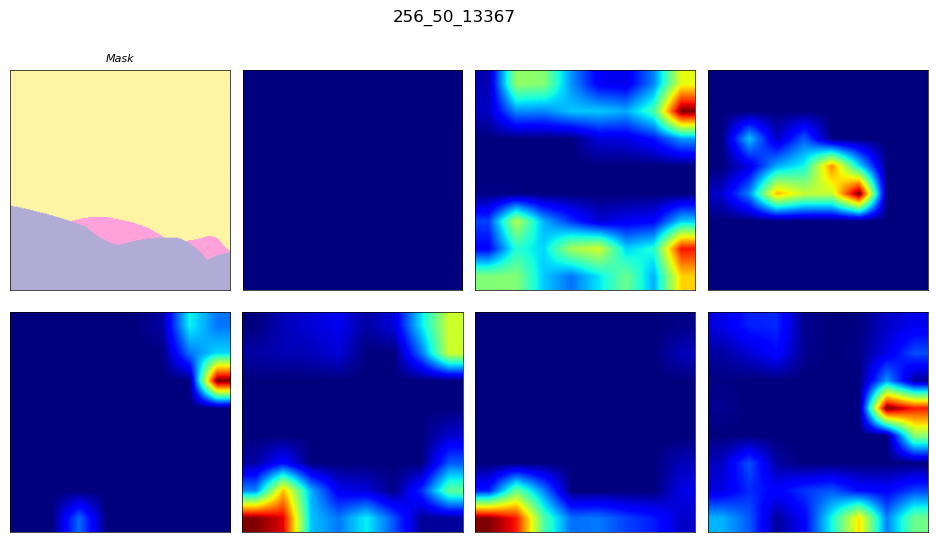

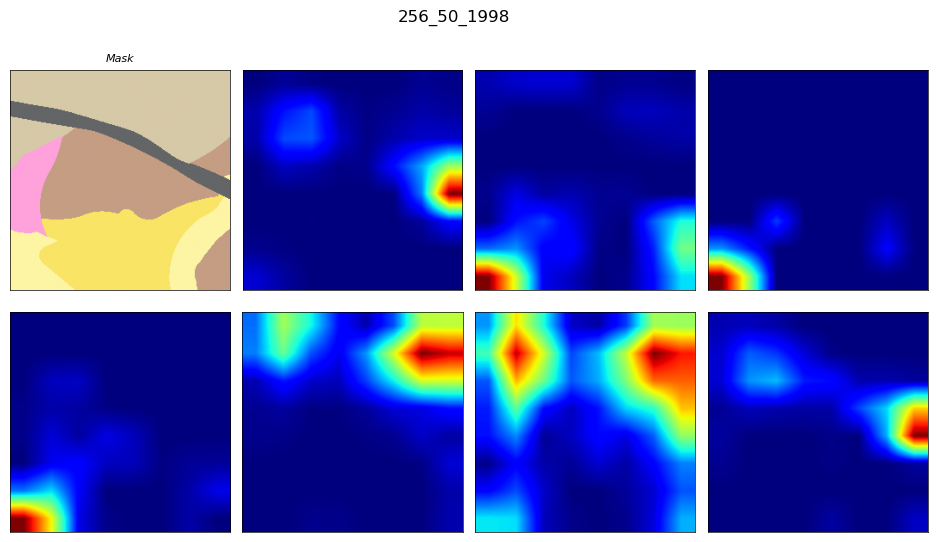

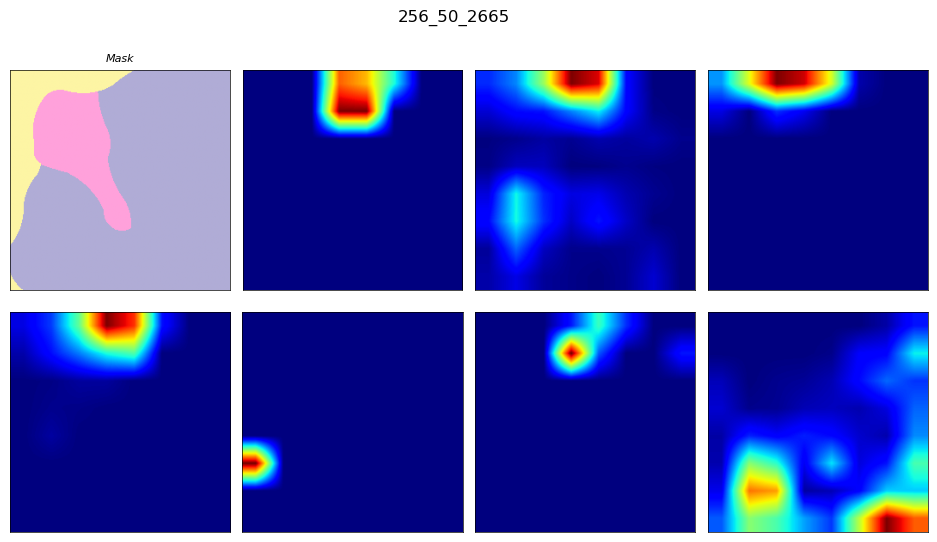

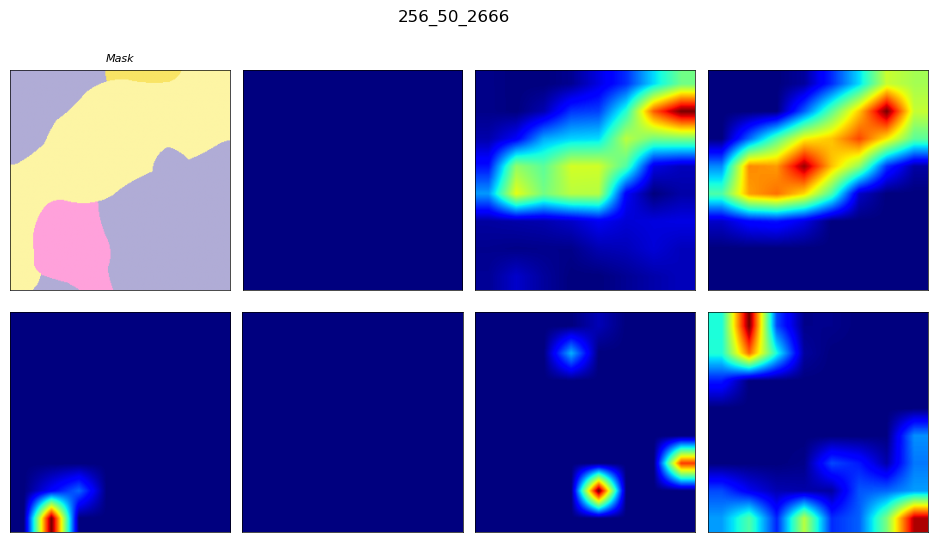

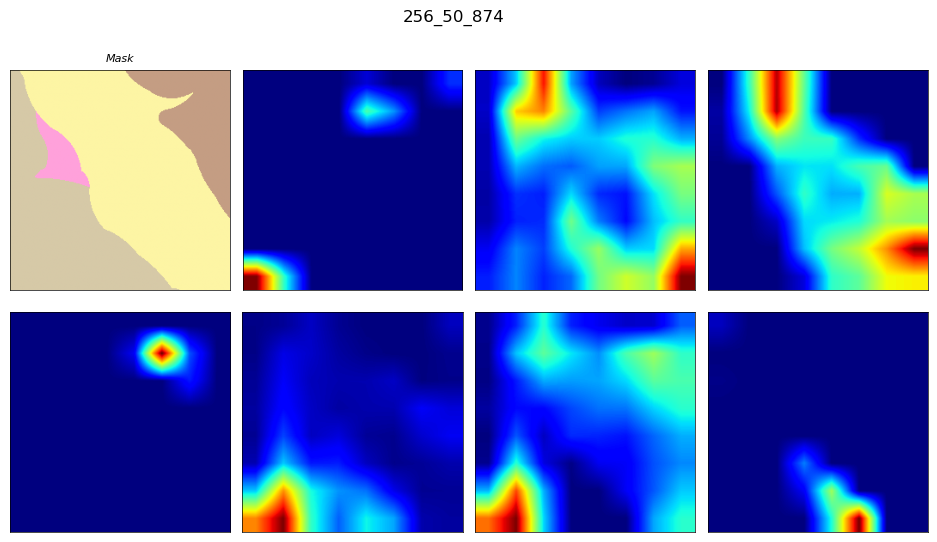

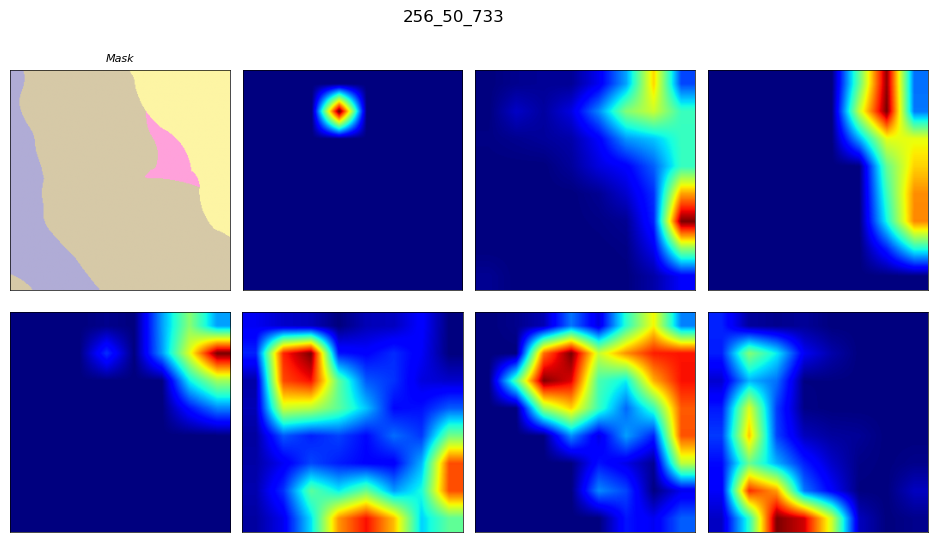

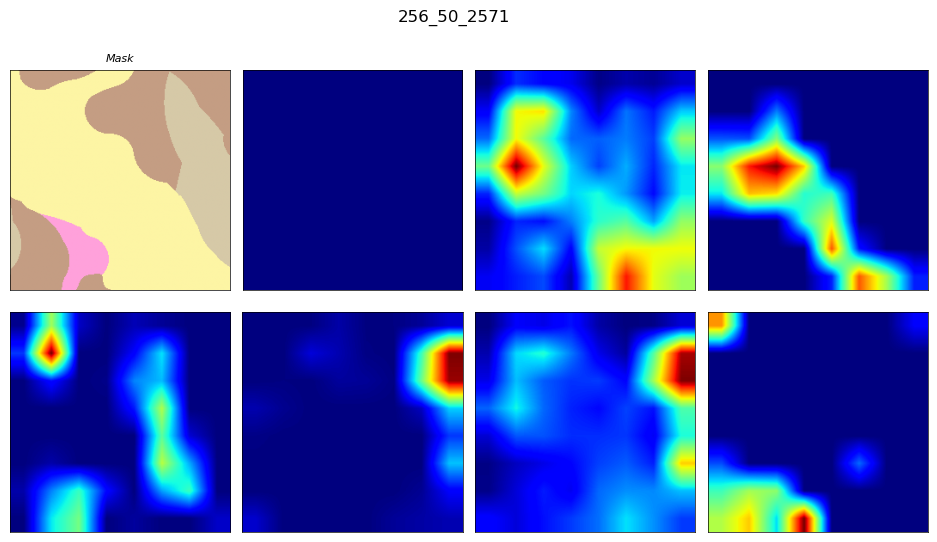

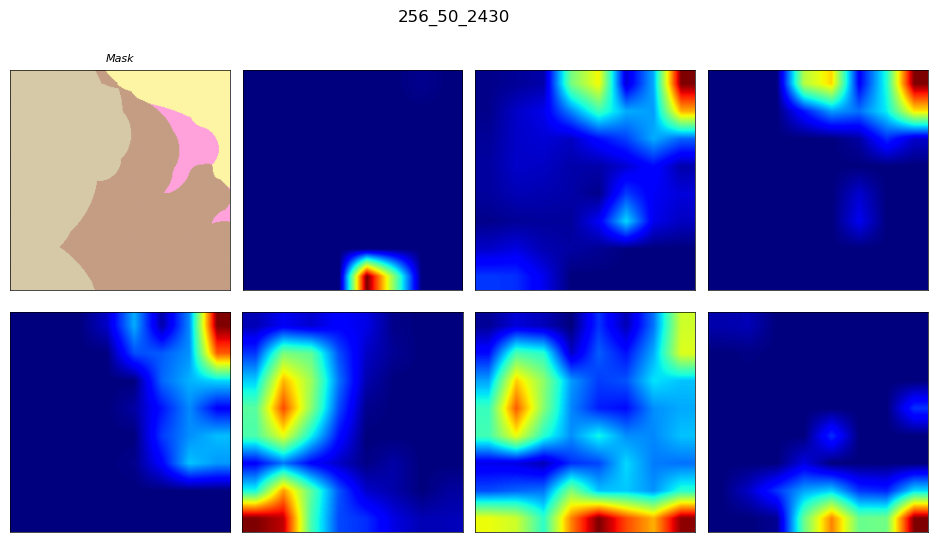

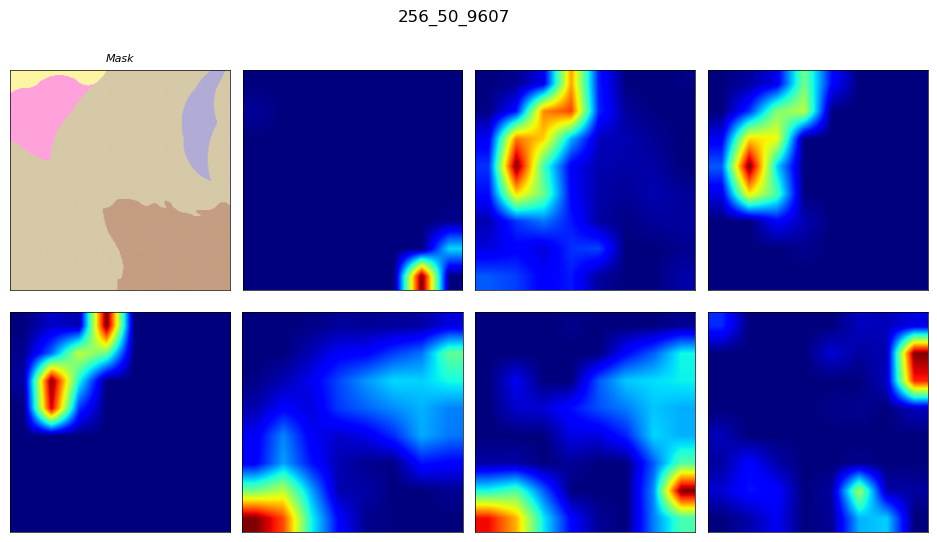

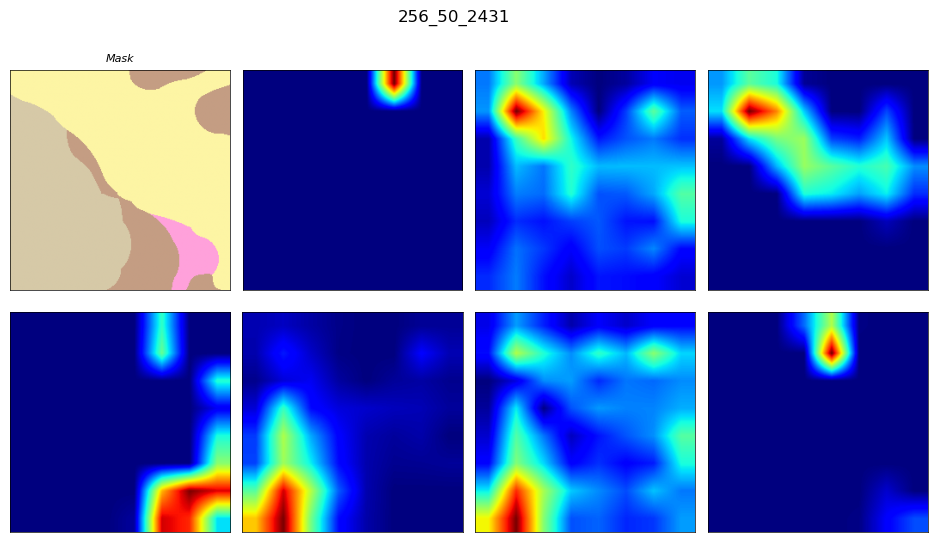

In [19]:

inference_dir = r'../experiments/sgmap-net/classification/gradcams/sgmap-net_dem_20260808_192756'
data_dir = r'../data/warren/patches'
plot_gradcams(inference_dir, data_dir)

### S-10

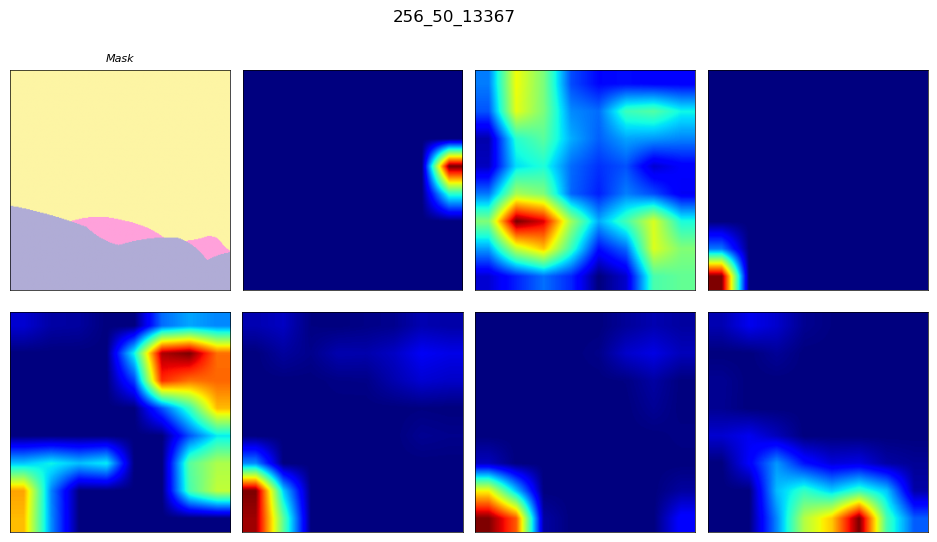

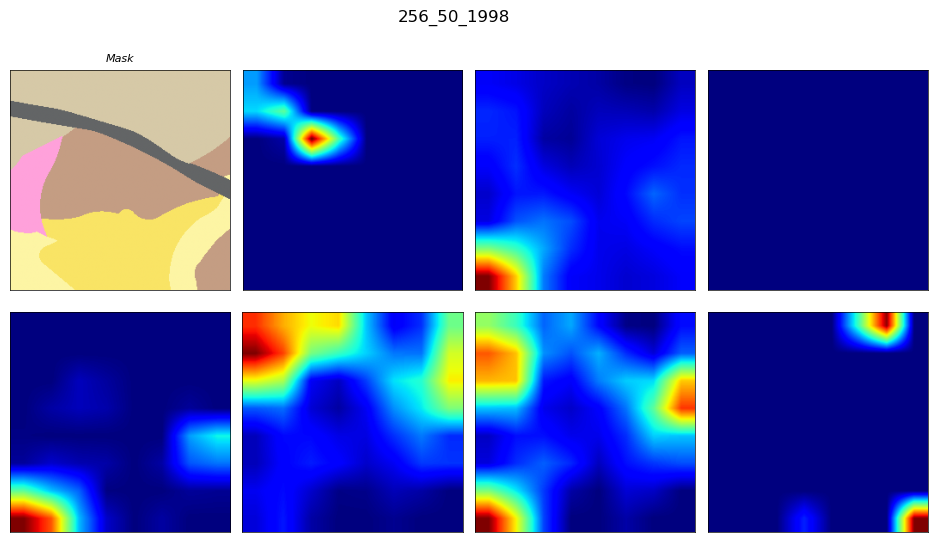

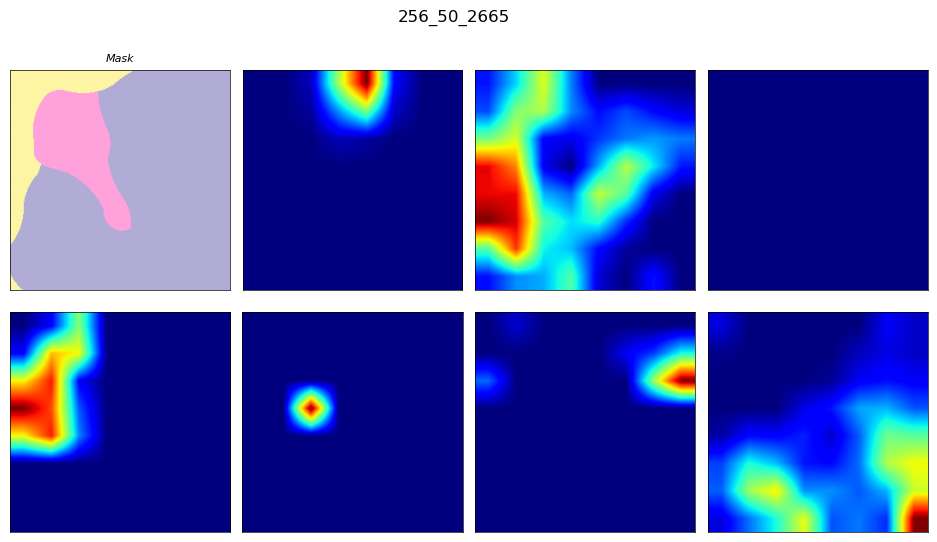

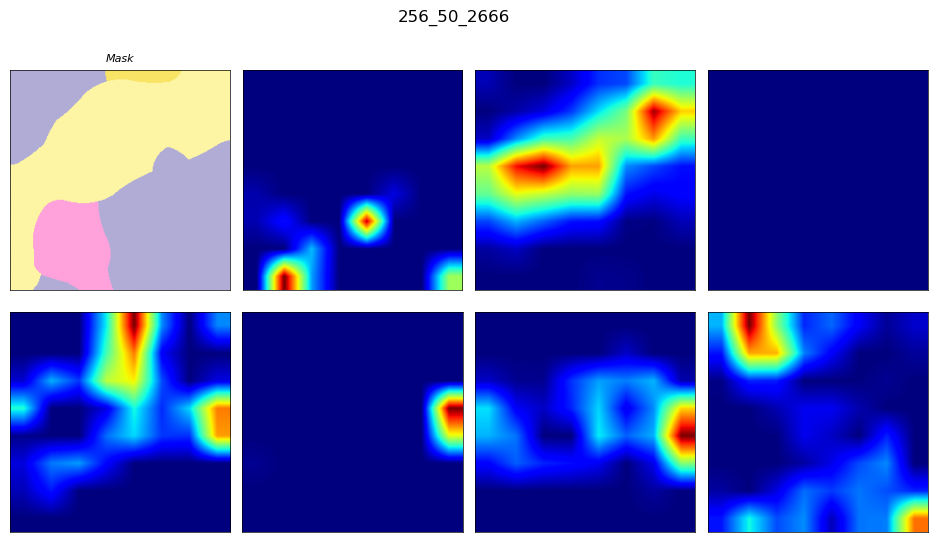

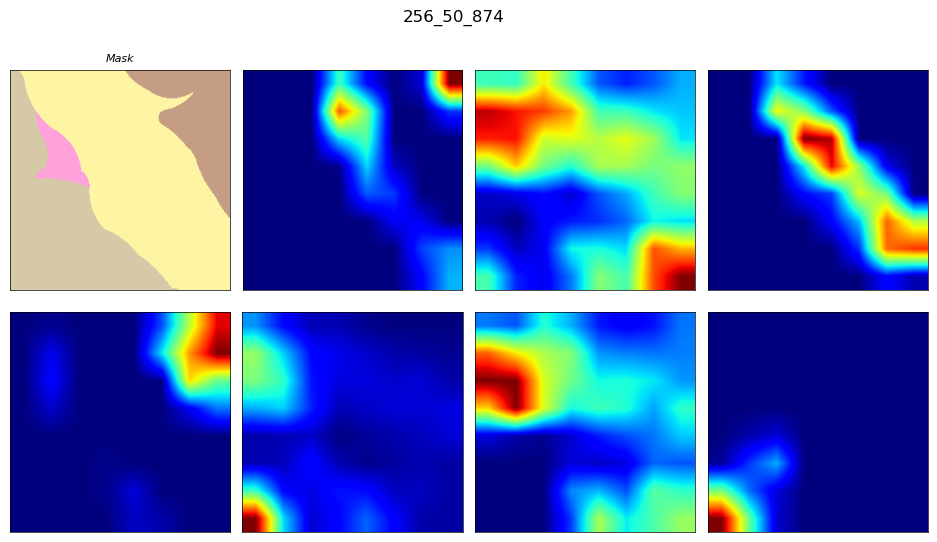

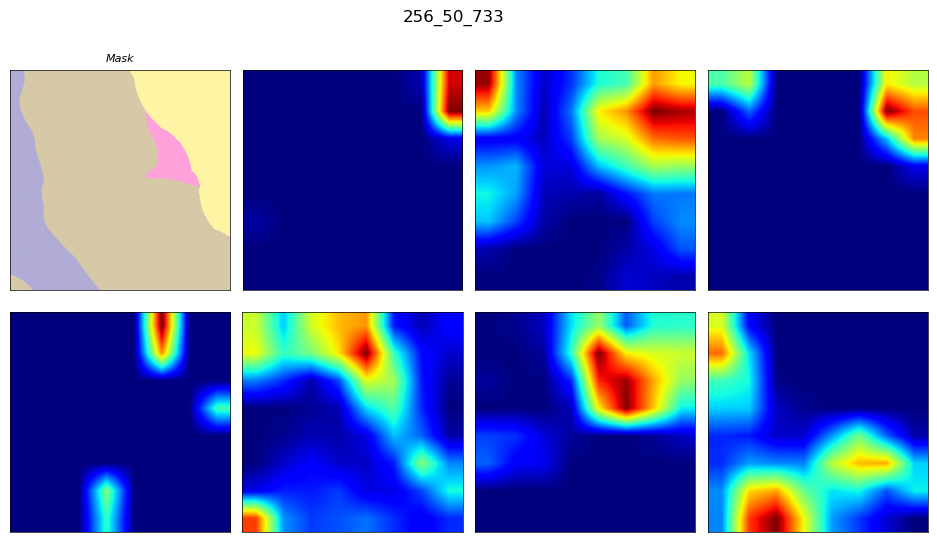

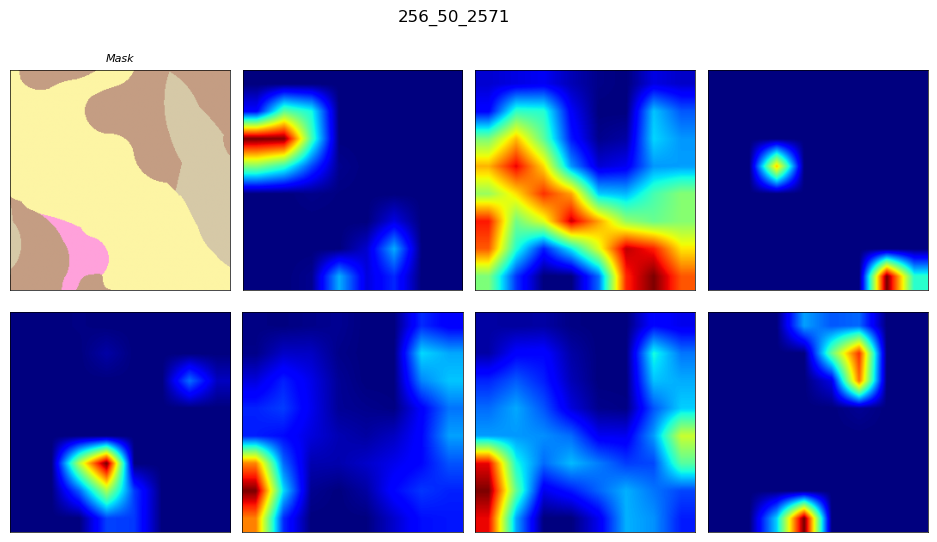

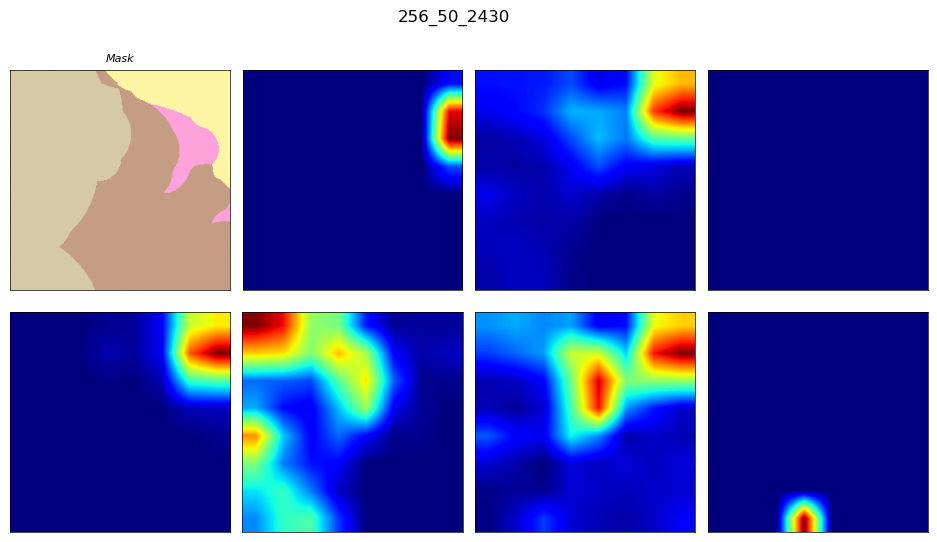

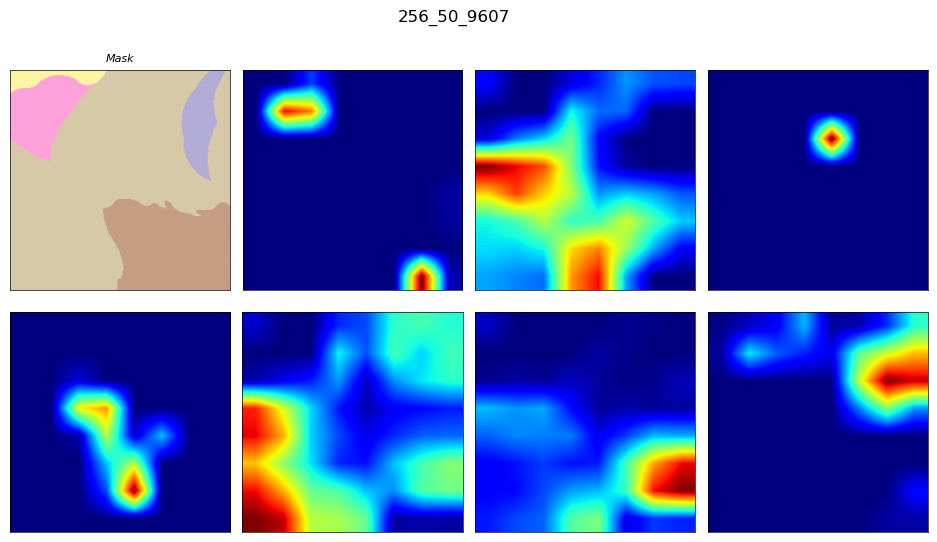

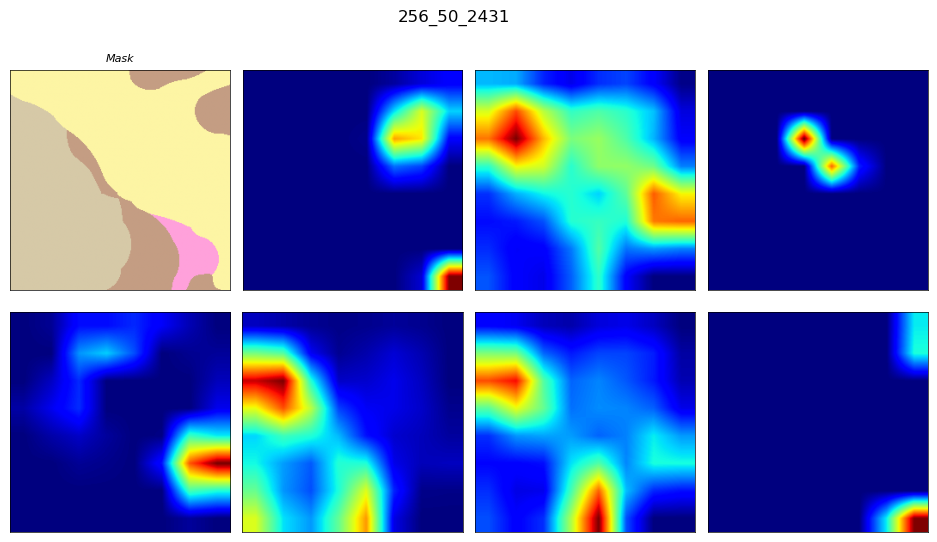

In [22]:
inference_dir = r'../experiments/sgmap-net/classification/gradcams/sgmap-net_s-10_20260808_192824'
data_dir = r'../data/warren/patches'
plot_gradcams(inference_dir, data_dir)

### PrC-ms

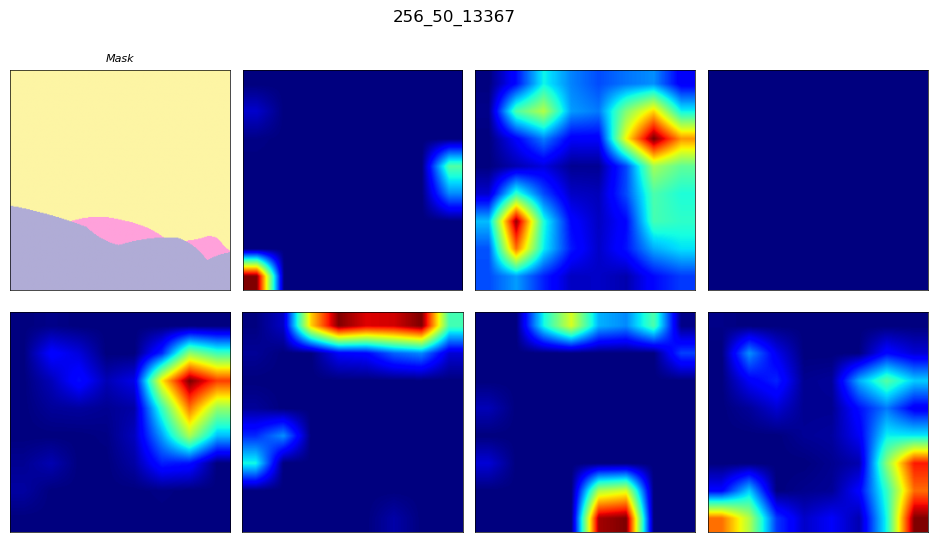

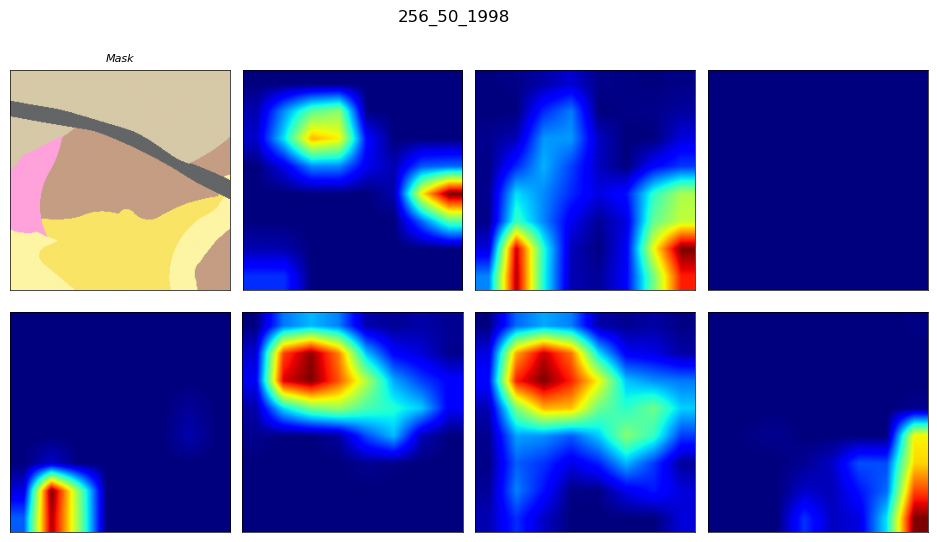

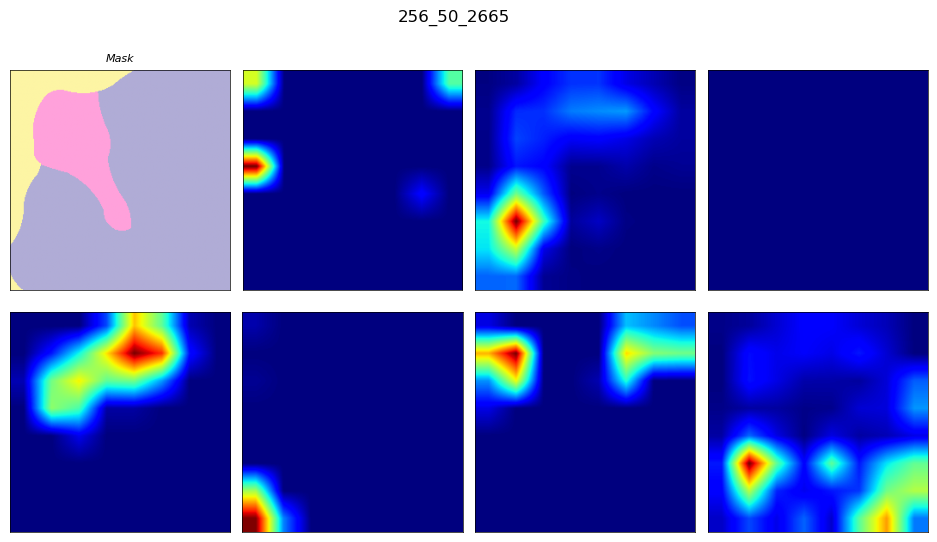

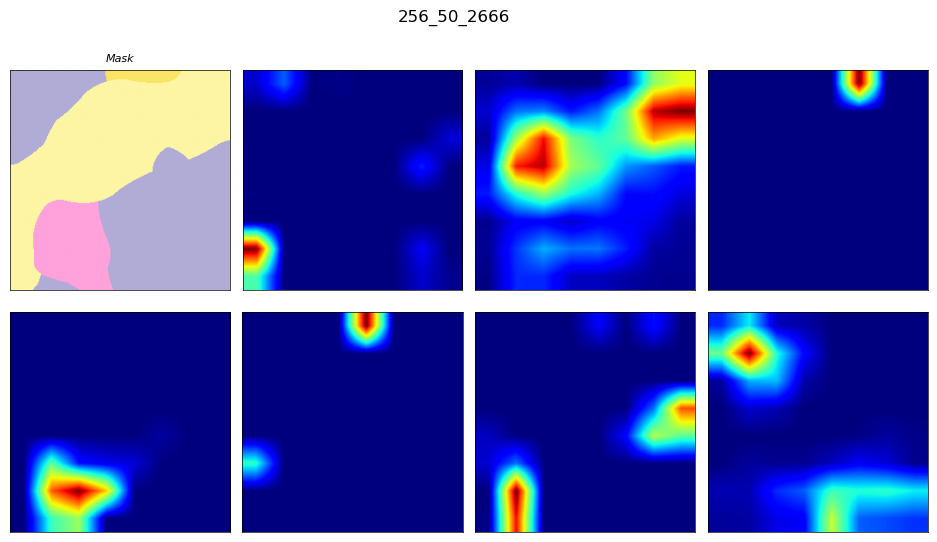

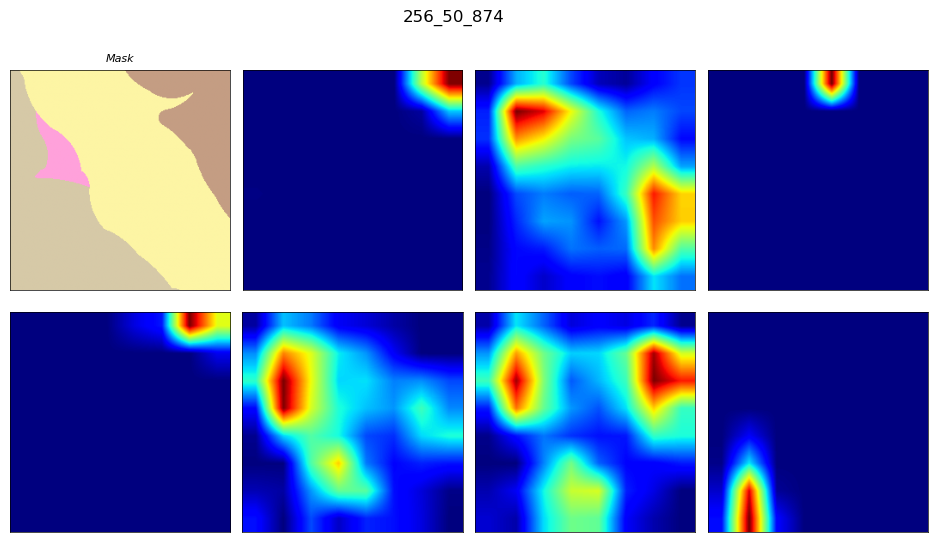

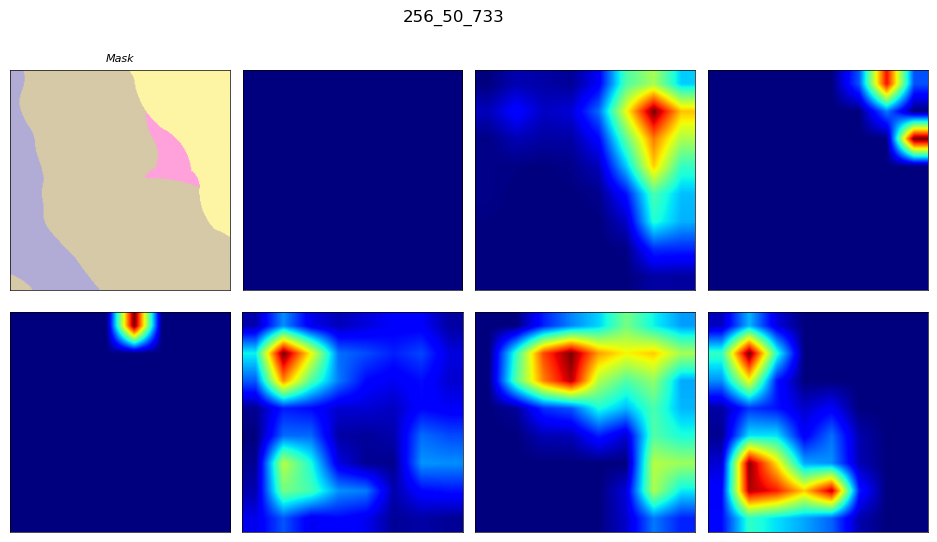

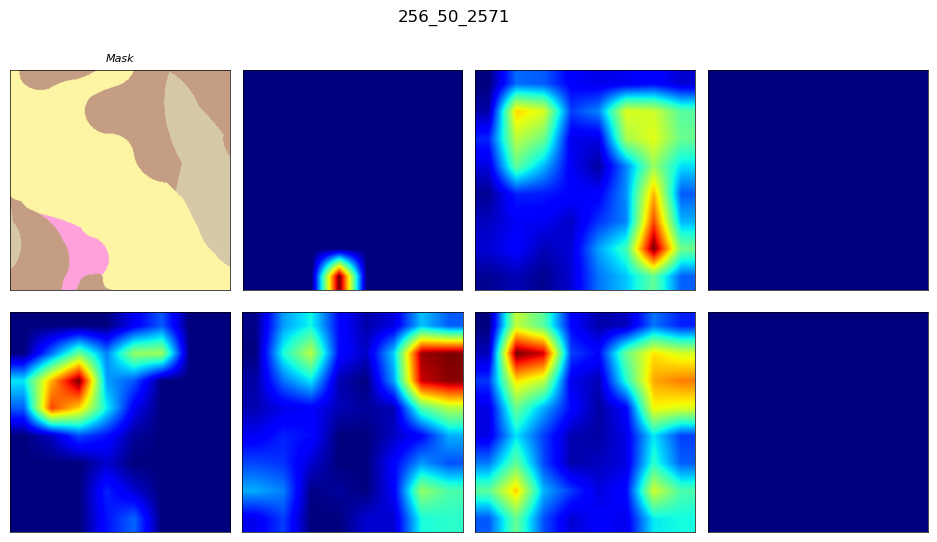

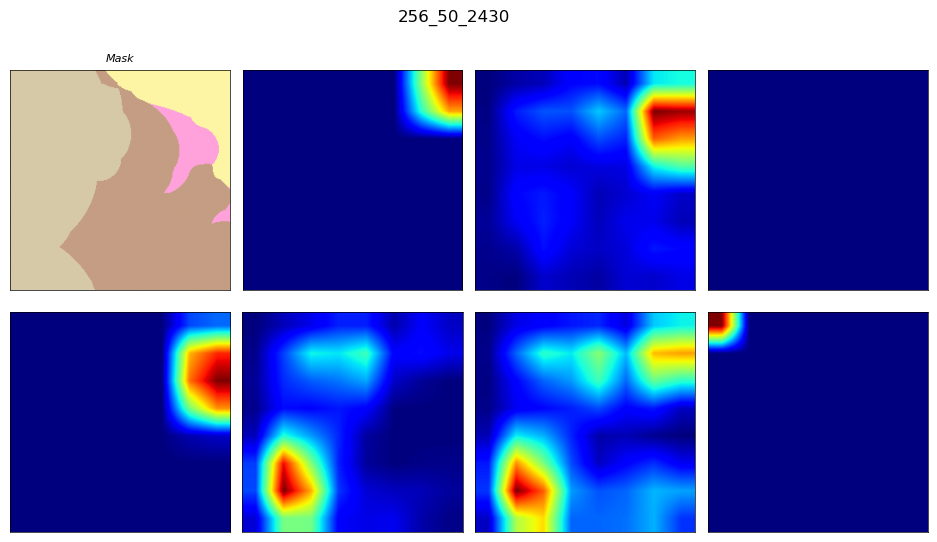

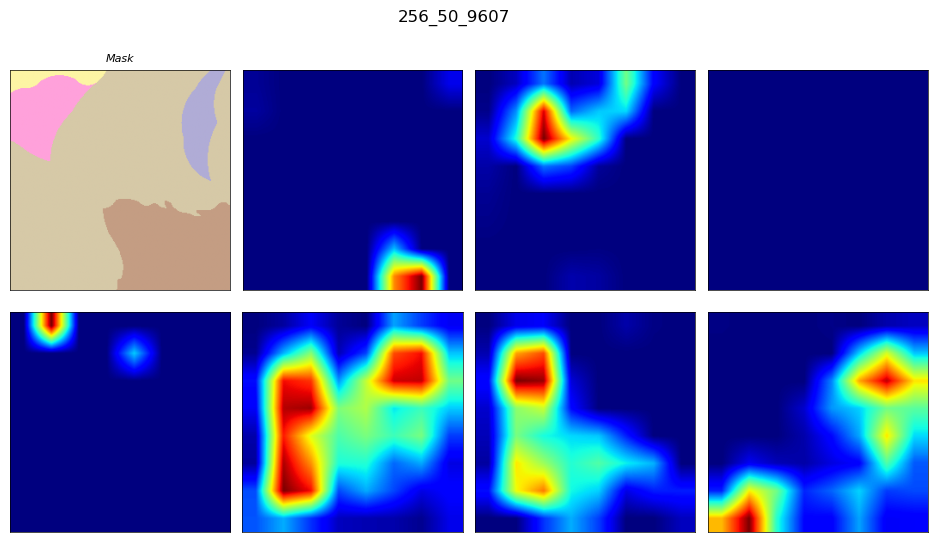

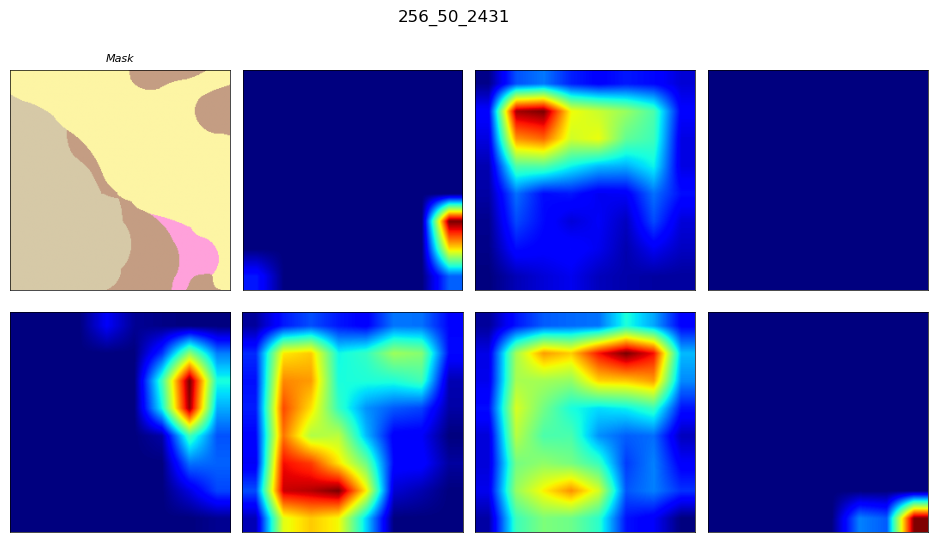

In [21]:
inference_dir = r'../experiments/sgmap-net/classification/gradcams/sgmap-net_prc-ms_20260808_193154'
data_dir = r'../data/warren/patches'
plot_gradcams(inference_dir, data_dir)

### PrC-ms + S-ms

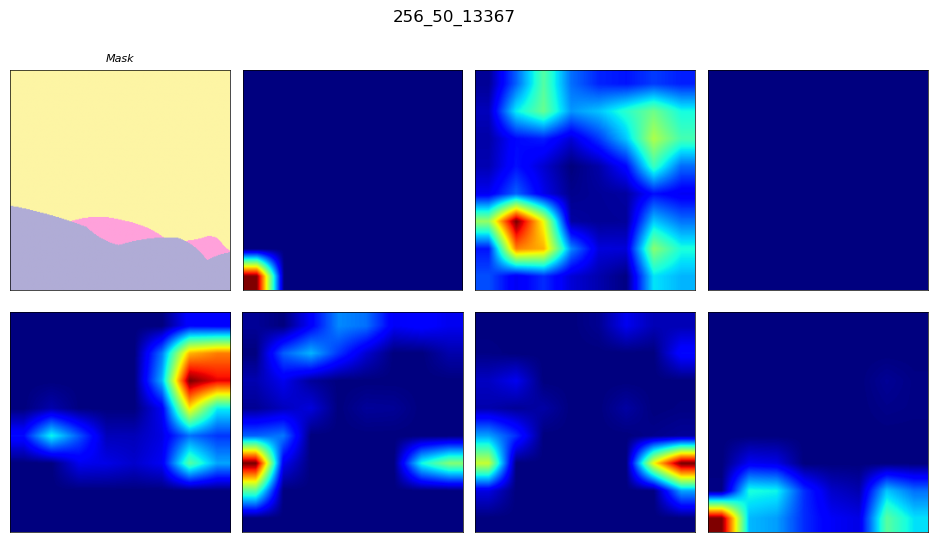

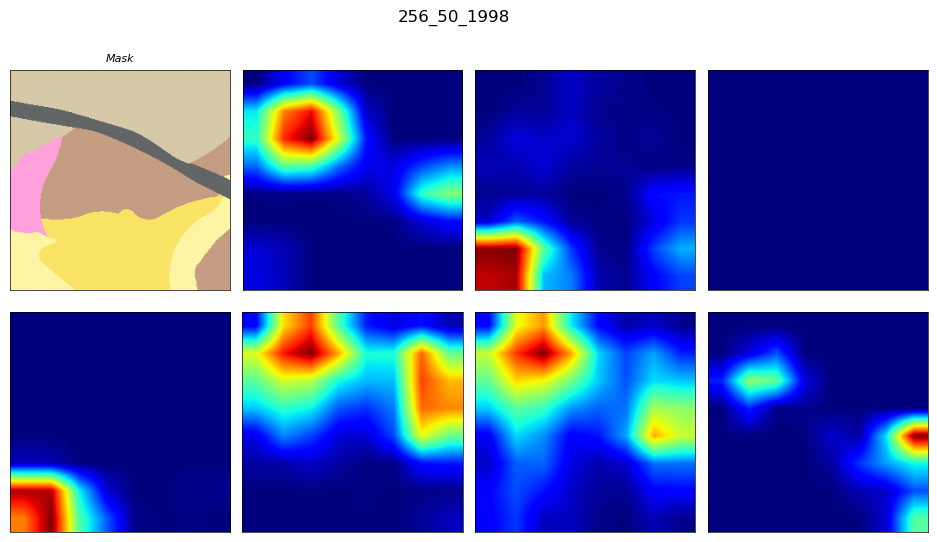

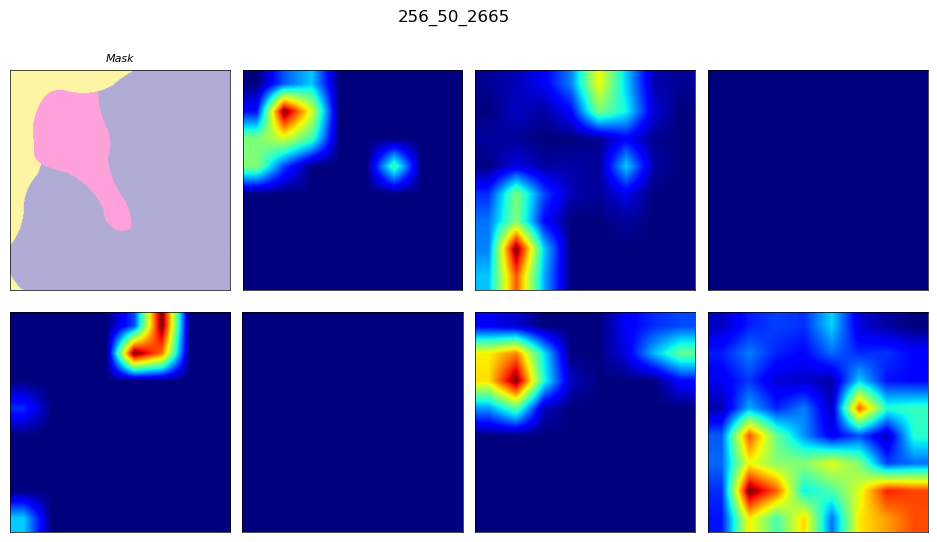

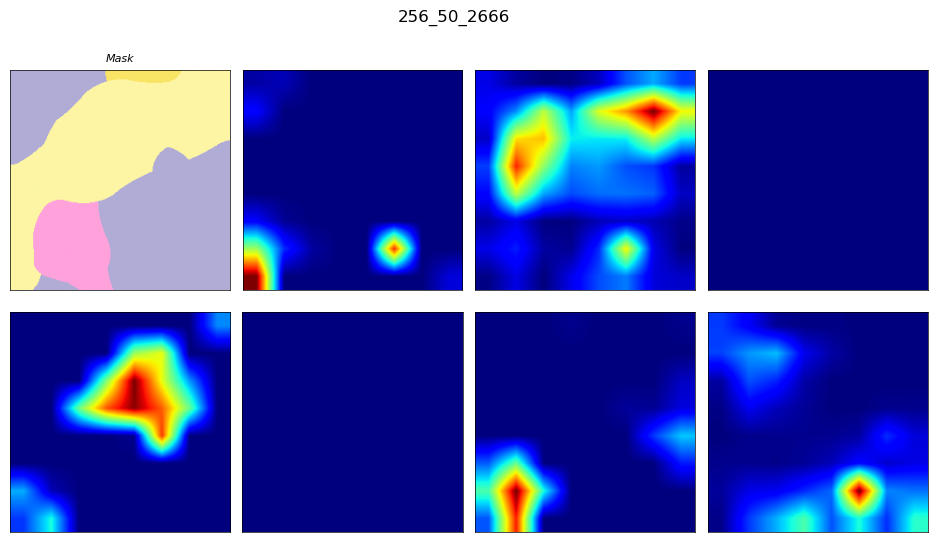

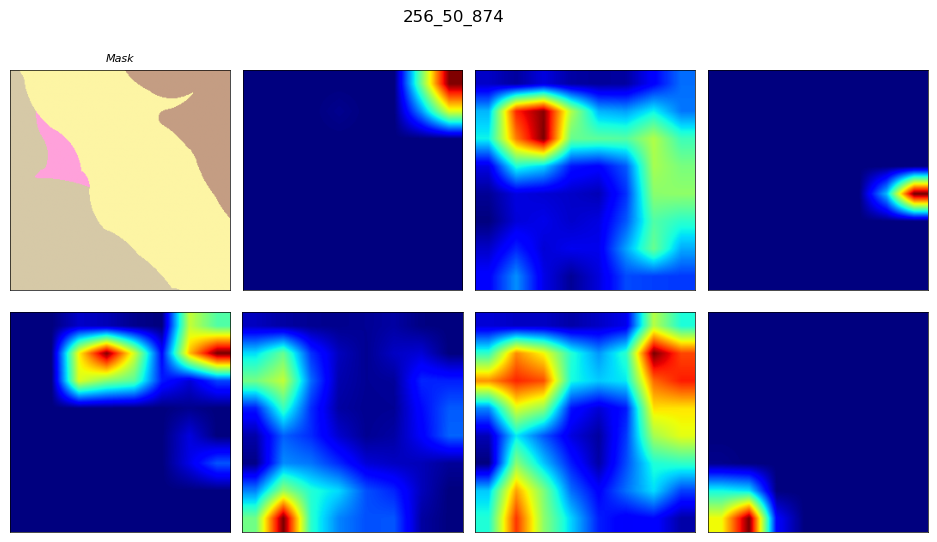

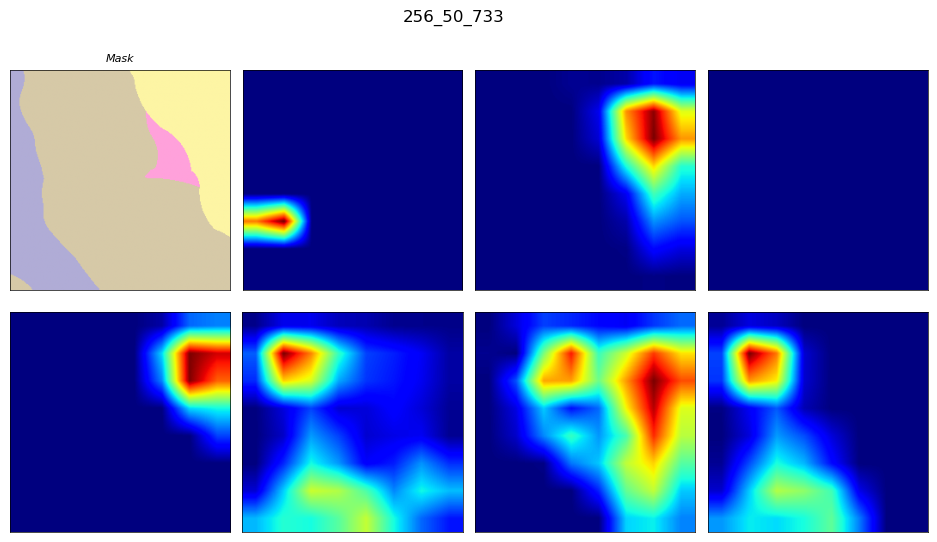

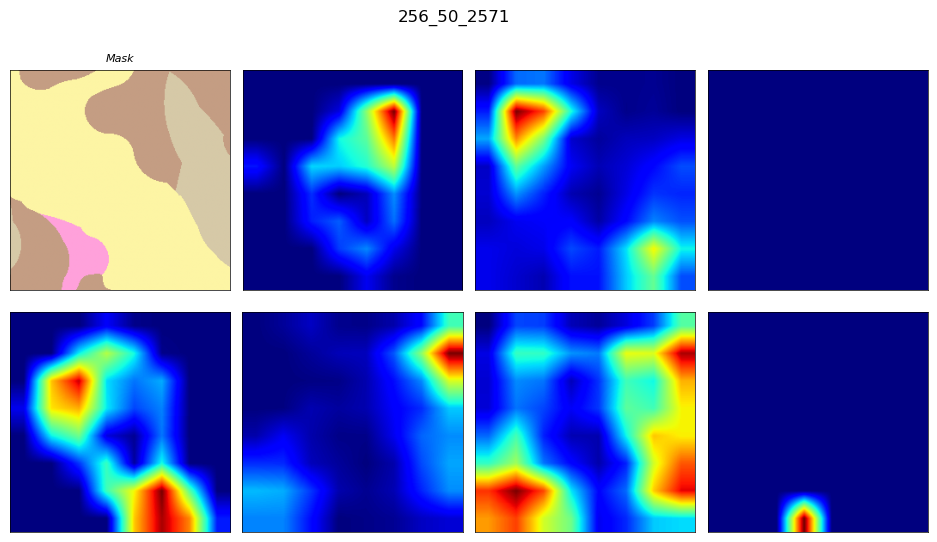

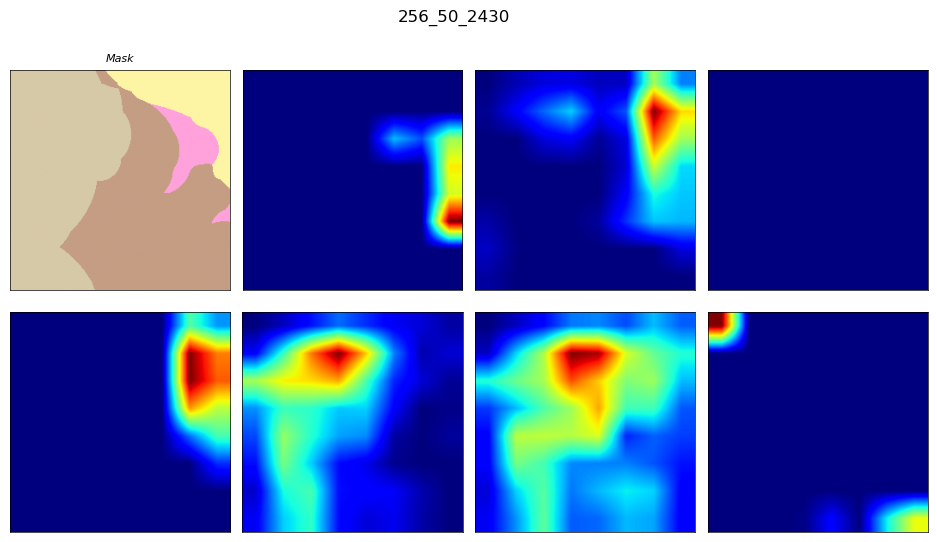

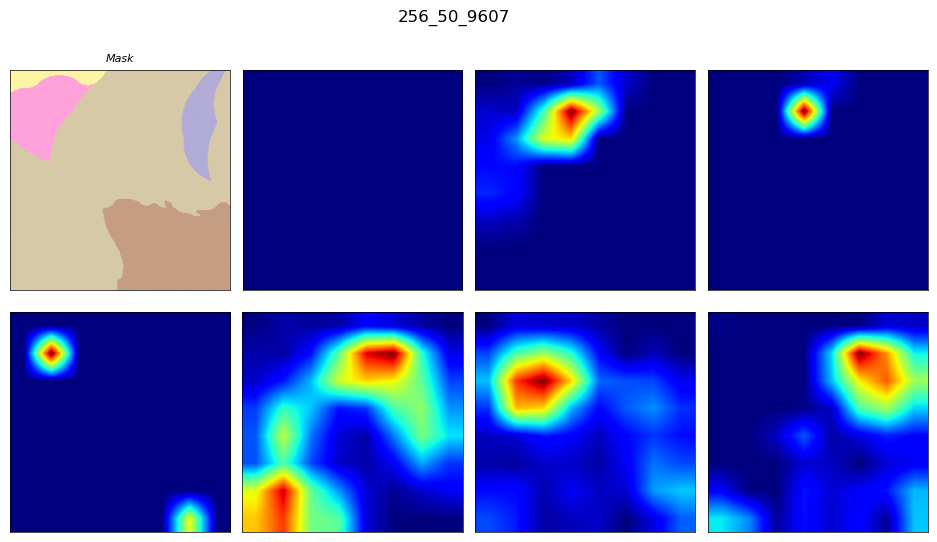

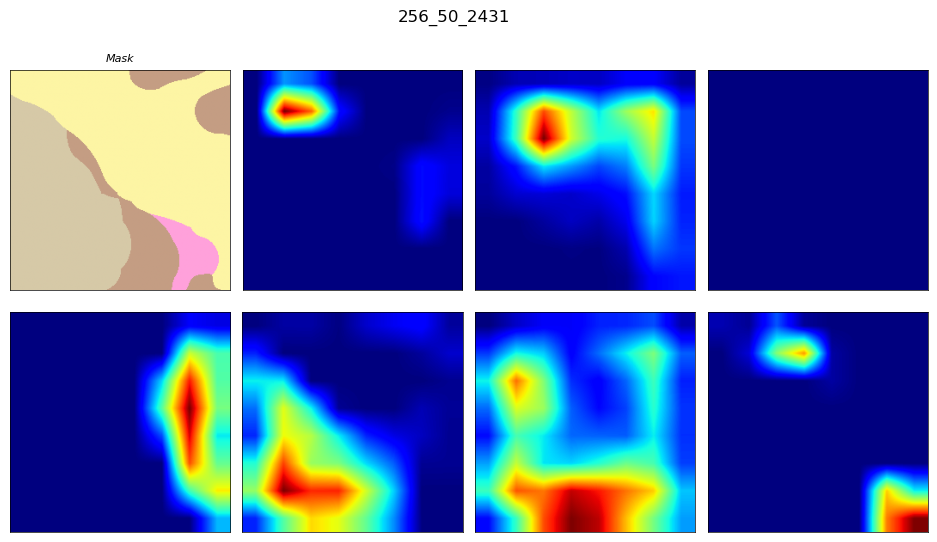

In [20]:
inference_dir = r'../experiments/sgmap-net/classification/gradcams/sgmap-net_prc-ms+s-ms_20260808_193232'
data_dir = r'../data/warren/patches'
plot_gradcams(inference_dir, data_dir)

# **Statistical Analysis**

## *Delta F1 vs. MMD Correlation*

In [6]:
def calculate_correlations(df, x_var='mmd (mu)', y_var='delta'):

    x = df[x_var]
    y = df[y_var]

    pcc,  p_pcc  = pearsonr(x, y)
    r2 = pcc**2
    srcc, p_srcc = spearmanr(x, y)
    krcc, p_krcc = kendalltau(x, y)

    return [r2, pcc, p_pcc, srcc, p_srcc, krcc, p_krcc]

In [15]:

mmd_path = r'../assets/sgmap-net/classification/mmd_summary.csv'

single_path = r'../assets/sgmap-net/classification/single_global.csv'

ms_path = r'../assets/sgmap-net/classification/multiscale_global.csv'

mm_path = r'../assets/sgmap-net/classification/multimodal_global.csv'


df_mmd = pd.read_csv(mmd_path)
df_single = pd.read_csv(single_path)
df_ms = pd.read_csv(ms_path)
df_ms.columns = [col.replace('_id', '_cd') for col in df_ms.columns]
df_mm = pd.read_csv(mm_path)
df_ms_mm = pd.concat([df_ms, df_mm], ignore_index=True)

results = []
for encoder in ['resnext50_32x4d', 'vit_b_16']:
    single = pd.merge(left=df_single[df_single['encoder'] == encoder], right=df_mmd.copy(), how='left', on='input')
    single['delta'] = single['macro_f1'] - single['macro_f1_cd']
    single_stats = calculate_correlations(single, 'mmd (mu)', 'delta')
    single_stats.insert(0, encoder)
    single_stats.insert(1, '-')
    single_stats.insert(2, len(single))
    results.append(single_stats)

    ms_mm = pd.merge(left=df_ms_mm[df_ms_mm['encoder'] == encoder], right=df_mmd.copy(), how='left', on='input')
    ms_mm['delta'] = ms_mm['macro_f1'] - ms_mm['macro_f1_cd']
    for fusion in ['stack', 'concat', 'ca']:
        ms_mm2 = ms_mm[ms_mm['fusion'] == fusion].copy()
        ms_mm_stats = calculate_correlations(ms_mm2, 'mmd (mu)', 'delta')
        ms_mm_stats.insert(0, encoder)
        ms_mm_stats.insert(1, fusion)
        ms_mm_stats.insert(2, len(ms_mm2))
        results.append(ms_mm_stats)

df_stats = pd.DataFrame(data=results, columns=['encoder', 'fusion', 'n', 'r2', 'pcc', 'pcc_p', 'srcc', 'srcc_p', 'krcc', 'krcc_p'])
df_stats.sort_values(['fusion', 'encoder'], ascending=[False, True], inplace=True)
df_stats.reset_index(drop=True, inplace=True)

df_stats.insert(loc=6, column='pcc_p_holm', value=0.0)
df_stats['pcc_p_holm'] = multipletests(df_stats["pcc_p"].values, method="holm")[1]

df_stats.insert(loc=9, column='srcc_p_holm', value=0.0)
df_stats['srcc_p_holm'] = multipletests(df_stats["srcc_p"].values, method='holm')[1]

df_stats['krcc_p_holm'] = multipletests(df_stats['krcc_p'].values, method='holm')[1]

df_stats.to_csv(r'../assets/sgmap-net/classification/correlation_fusion.csv', index=False)
df_stats

,encoder,fusion,n,r2,pcc,pcc_p,pcc_p_holm,srcc,srcc_p,srcc_p_holm,krcc,krcc_p,krcc_p_holm
0,resnext50_32x4d,stack,15,0.135822,0.368541,0.176477,0.451090,0.639286,0.010288,0.041154,0.504762,0.008270,0.033080
1,vit_b_16,stack,15,0.737065,0.858525,0.000042,0.000293,0.728571,0.002065,0.010326,0.542857,0.004143,0.020714
2,resnext50_32x4d,concat,15,0.247441,0.497434,0.059201,0.236805,0.453571,0.089486,0.178972,0.333333,0.092643,0.185285
3,vit_b_16,concat,15,0.728813,0.853705,0.000051,0.000309,0.807143,0.000275,0.001927,0.657143,0.000330,0.002313
4,resnext50_32x4d,ca,15,0.081701,0.285833,0.301727,0.451090,0.317857,0.248291,0.248291,0.257143,0.201843,0.201843
5,vit_b_16,ca,15,0.823558,0.907501,0.000003,0.000024,0.853571,0.000052,0.000414,0.695238,0.000118,0.000941
6,resnext50_32x4d,-,35,0.061653,0.248300,0.150363,0.451090,0.367507,0.029864,0.089593,0.233613,0.048382,0.145146
7,vit_b_16,-,35,0.357504,0.597916,0.000149,0.000744,0.513165,0.001619,0.009714,0.371429,0.001698,0.010188


## *Fusion Comparison Paired t-test*

In [ ]:

ms_path = r'../assets/sgmap-net/classification/multiscale_global.csv'

mm_path = r'../assets/sgmap-net/classification/multimodal_global.csv'


df_ms = pd.read_csv(ms_path)
df_ms.columns = [col.replace('_id', '_cd') for col in df_ms.columns]
df_mm = pd.read_csv(mm_path)
df_ms_mm = pd.concat([df_ms, df_mm], ignore_index=True)

df = pd.DataFrame(columns = ['encoder', 'domain', 'comparison', 'n', 'mean_diff', 't', 'p', 'w', 'w_p'], index=[0])
idx = 0
for encoder in ['resnext50_32x4d', 'vit_b_16']:
    encoder_mask = df_ms_mm['encoder'] == encoder
    subset = df_ms_mm[encoder_mask].copy()
    stack_mask = subset['fusion'] == 'stack'
    concat_mask = subset['fusion'] == 'concat'
    ca_mask = subset['fusion'] == 'ca'


    ##### in-domain...
    # 1. stack vs. concatenation
    a = subset.loc[stack_mask, 'macro_f1']
    b = subset.loc[concat_mask, 'macro_f1']
    id_ttest = ttest_rel(a, b, alternative="two-sided")
    id_wilcoxon = wilcoxon(a, b, alternative='two-sided')

    df.loc[idx, 'encoder'] = encoder
    df.loc[idx, 'domain'] = 'id'
    df.loc[idx, 'comparison'] = r'stack=concat'
    df.loc[idx, 'n'] = len(a)
    df.loc[idx, 'mean_diff'] = a.mean() - b.mean()
    df.loc[idx, 't'] = id_ttest.statistic.item()
    df.loc[idx, 'p'] = id_ttest.pvalue.item()
    df.loc[idx, 'w'] = id_wilcoxon.statistic.item()
    df.loc[idx, 'w_p'] = id_wilcoxon.pvalue.item()

    idx += 1

    # 2. stack vs. cross-attention
    a = subset.loc[stack_mask, 'macro_f1']
    b = subset.loc[ca_mask, 'macro_f1']
    id_ttest = ttest_rel(a, b, alternative="two-sided")
    id_wilcoxon = wilcoxon(a, b, alternative='two-sided')
    stats.append(id_ttest.statistic.item())
    stats.append(id_ttest.pvalue.item())

    df.loc[idx, 'encoder'] = encoder
    df.loc[idx, 'domain'] = 'id'
    df.loc[idx, 'comparison'] = r'stack=ca'
    df.loc[idx, 'n'] = len(a)
    df.loc[idx, 'mean_diff'] = a.mean() - b.mean()
    df.loc[idx, 't'] = id_ttest.statistic.item()
    df.loc[idx, 'p'] = id_ttest.pvalue.item()
    df.loc[idx, 'w'] = id_wilcoxon.statistic.item()
    df.loc[idx, 'w_p'] = id_wilcoxon.pvalue.item()

    idx += 1

    # 3. concatenation vs. cross-attention
    a = subset.loc[concat_mask, 'macro_f1']
    b = subset.loc[ca_mask, 'macro_f1']
    id_ttest = ttest_rel(a, b, alternative="two-sided")
    id_wilcoxon = wilcoxon(a, b, alternative='two-sided')
    stats.append(id_ttest.statistic.item())
    stats.append(id_ttest.pvalue.item())

    df.loc[idx, 'encoder'] = encoder
    df.loc[idx, 'domain'] = 'id'
    df.loc[idx, 'comparison'] = r'concat=ca'
    df.loc[idx, 'n'] = len(a)
    df.loc[idx, 'mean_diff'] = a.mean() - b.mean()
    df.loc[idx, 't'] = id_ttest.statistic.item()
    df.loc[idx, 'p'] = id_ttest.pvalue.item()
    df.loc[idx, 'w'] = id_wilcoxon.statistic.item()
    df.loc[idx, 'w_p'] = id_wilcoxon.pvalue.item()

    idx += 1


    ##### cross-domain...
    # 1. stack vs. concatenation
    a = subset.loc[stack_mask, 'macro_f1_cd']
    b = subset.loc[concat_mask, 'macro_f1_cd']
    cd_ttest = ttest_rel(a, b, alternative="two-sided")
    cd_wilcoxon = wilcoxon(a, b, alternative='two-sided')
    stats.append(cd_ttest.statistic.item())
    stats.append(cd_ttest.pvalue.item())

    df.loc[idx, 'encoder'] = encoder
    df.loc[idx, 'domain'] = 'cd'
    df.loc[idx, 'comparison'] = r'stack=concat'
    df.loc[idx, 'n'] = len(a)
    df.loc[idx, 'mean_diff'] = a.mean() - b.mean()
    df.loc[idx, 't'] = cd_ttest.statistic.item()
    df.loc[idx, 'p'] = cd_ttest.pvalue.item()
    df.loc[idx, 'w'] = cd_wilcoxon.statistic.item()
    df.loc[idx, 'w_p'] = cd_wilcoxon.pvalue.item()

    idx += 1

    # 2. stack vs. cross-attention
    a = subset.loc[stack_mask, 'macro_f1_cd']
    b = subset.loc[ca_mask, 'macro_f1_cd']
    cd_ttest = ttest_rel(a, b, alternative="two-sided")
    cd_wilcoxon = wilcoxon(a, b, alternative='two-sided')
    stats.append(cd_ttest.statistic.item())
    stats.append(cd_ttest.pvalue.item())

    df.loc[idx, 'encoder'] = encoder
    df.loc[idx, 'domain'] = 'cd'
    df.loc[idx, 'comparison'] = r'stack=ca'
    df.loc[idx, 'n'] = len(a)
    df.loc[idx, 'mean_diff'] = a.mean() - b.mean()
    df.loc[idx, 't'] = cd_ttest.statistic.item()
    df.loc[idx, 'p'] = cd_ttest.pvalue.item()
    df.loc[idx, 'w'] = cd_wilcoxon.statistic.item()
    df.loc[idx, 'w_p'] = cd_wilcoxon.pvalue.item()

    idx += 1
    
    # 3. concatenation vs. cross-attention
    a = subset.loc[concat_mask, 'macro_f1_cd']
    b = subset.loc[ca_mask, 'macro_f1_cd']
    cd_ttest = ttest_rel(a, b, alternative="two-sided")
    cd_wilcoxon = wilcoxon(a, b, alternative='two-sided')
    stats.append(cd_ttest.statistic.item())
    stats.append(cd_ttest.pvalue.item())

    df.loc[idx, 'encoder'] = encoder
    df.loc[idx, 'domain'] = 'cd'
    df.loc[idx, 'comparison'] = r'concat=ca'
    df.loc[idx, 'n'] = len(a)
    df.loc[idx, 'mean_diff'] = a.mean() - b.mean()
    df.loc[idx, 't'] = cd_ttest.statistic.item()
    df.loc[idx, 'p'] = cd_ttest.pvalue.item()
    df.loc[idx, 'w'] = cd_wilcoxon.statistic.item()
    df.loc[idx, 'w_p'] = cd_wilcoxon.pvalue.item()

    idx += 1


df.insert(loc=7, column='cohens_d', value=0.0)
df['cohens_d'] = df['t'] / np.sqrt(df['n'].astype(float))

df.insert(loc=7, column='p_holm', value=0.0)
df['p_holm'] = (df.groupby(['encoder', 'domain'])['p'].transform(lambda x: multipletests(x, method='holm')[1]))

df['w_p_holm'] = (df.groupby(["encoder", "domain"])["w_p"].transform(lambda x: multipletests(x, method="holm")[1]))

df.to_csv(r'../assets/sgmap-net/classification/fusion_comparisons.csv')

df

,encoder,domain,comparison,n,mean_diff,t,p,p_holm,cohens_d,w,w_p,w_p_holm
0,resnext50_32x4d,id,stack=concat,15,0.057677,8.045319,0.000001,0.000003,2.077292,0.0,0.000061,0.000183
1,resnext50_32x4d,id,stack=ca,15,0.048209,10.209222,0.0,0.0,2.63601,0.0,0.000061,0.000183
2,resnext50_32x4d,id,concat=ca,15,-0.009469,-1.018773,0.325594,0.325594,-0.263046,56.0,0.846924,0.846924
3,resnext50_32x4d,cd,stack=concat,15,0.037302,2.166877,0.047983,0.143949,0.559485,22.0,0.030151,0.076721
4,resnext50_32x4d,cd,stack=ca,15,0.01492,0.938728,0.363785,0.363785,0.242378,41.0,0.302795,0.302795
5,resnext50_32x4d,cd,concat=ca,15,-0.022382,-1.870691,0.082438,0.164876,-0.48301,21.0,0.025574,0.076721
6,vit_b_16,id,stack=concat,15,-0.003462,-1.120561,0.28133,0.409222,-0.289327,38.0,0.229309,0.229309
7,vit_b_16,id,stack=ca,15,0.005925,1.330528,0.204611,0.409222,0.343541,31.0,0.106995,0.213989
8,vit_b_16,id,concat=ca,15,0.009387,2.024929,0.062382,0.187146,0.522834,26.0,0.055359,0.166077
9,vit_b_16,cd,stack=concat,15,0.013123,1.608803,0.12997,0.12997,0.415391,32.0,0.120544,0.120544


# **Segmentation**

## *Experiments Compilation*

### Global

In [33]:

output_dir = r'../assets/sgmap-net/segmentation'
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)

dirs = glob.glob(r'../experiments/sgmap-net/segmentation/exploration/*')

dfs = []
for d in dirs:
    model = os.path.basename(d).split('_')[0]
    model = model.split('-')[0]
    exp_type = 'stack'
    input = os.path.basename(d).split('_')[1]
    df = pd.DataFrame({'model': model, 'exp_type': exp_type, 'input': input}, index=[0])

    id_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_path)
    cd_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_path)
    id_cd = pd.merge(left=id, right=cd, how='inner', left_index=True, right_index=True, suffixes=['', '_cd'])
    df = df.merge(id_cd, how='inner', left_index=True, right_index=True)
    dfs.append(df)

df = pd.concat(dfs)

sort_list = ['dem', 'ep-5', 'ep-51', 's-5', 's-50', 'ep-ms', 's-ms', 'dem+rgb', 'ep-ms+prc-ms+s-ms']
sort_map = {input: idx for idx, input in enumerate(sort_list)}
df['_order'] = df['input'].map(sort_map)
df = (df.sort_values(["_order", "model"]).drop(columns="_order").reset_index(drop=True))

output_path = os.path.join(output_dir, 'global.csv')
df.to_csv(output_path, index=False)

df.head()

,model,exp_type,input,macro_iou,macro_dice,macro_precision,macro_recall,micro_iou,micro_dice,micro_precision,...,macro_iou_cd,macro_dice_cd,macro_precision_cd,macro_recall_cd,micro_iou_cd,micro_dice_cd,micro_precision_cd,micro_recall_cd,mean_hd_cd,mean_hd95_cd
0,deeplabv3p,stack,dem,0.485936,0.547511,0.615950,0.550938,0.782824,0.878184,0.878184,...,0.355869,0.414791,0.497504,0.440736,0.658800,0.794309,0.794309,0.794309,105.753320,87.017567
1,segformer,stack,dem,0.511640,0.575711,0.631775,0.584989,0.791916,0.883876,0.883876,...,0.411651,0.474433,0.535311,0.496081,0.689442,0.816177,0.816177,0.816177,96.407649,78.882213
2,deeplabv3p,stack,ep-5,0.448181,0.512881,0.582321,0.527506,0.742038,0.851919,0.851919,...,0.378123,0.423494,0.486132,0.461321,0.662850,0.797246,0.797246,0.797246,96.114120,79.962934
3,segformer,stack,ep-5,0.459605,0.525416,0.593606,0.536170,0.748342,0.856059,0.856059,...,0.400255,0.446550,0.494462,0.483756,0.670013,0.802405,0.802405,0.802405,88.649134,73.340653
4,deeplabv3p,stack,ep-51,0.453190,0.521006,0.581195,0.533241,0.747740,0.855665,0.855665,...,0.377696,0.426043,0.470666,0.465449,0.652004,0.789349,0.789349,0.789349,93.595492,78.069010


### Class-wise

In [34]:

class_dirs = glob.glob(r'../experiments/sgmap-net/segmentation/exploration/*')

sort_list = ['dem', 'ep-5', 'ep-51', 's-5', 's-50', 'ep-ms', 's-ms', 'dem+rgb', 'ep-ms+prc-ms+s-ms']
sort_map = {input: idx for idx, input in enumerate(sort_list)}

iou = []
dice = []
for idx, d in enumerate(class_dirs):
    model = os.path.basename(d).split('_')[0]
    model = model.split('-')[0]
    exp_type = 'stack'
    input = os.path.basename(d).split('_')[1]
    df = pd.DataFrame({'model': model, 'exp_type': exp_type, 'input': input}, index=[0])
    
    id = pd.read_csv(os.path.join(d, 'id_overall_class.csv')).set_index('class')
    cd = pd.read_csv(os.path.join(d, 'cd_overall_class.csv')).set_index('class')

    id_cd_iou = pd.concat([id['macro_iou'], cd['macro_iou'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_iou = pd.merge(left=df.copy(), right=id_cd_iou, left_index=True, right_index=True)
    iou.append(df_iou)

    id_cd_dice = pd.concat([id['macro_dice'], cd['macro_dice'].add_suffix("_cd")]).to_frame().T.reset_index(drop=True)
    df_dice = pd.merge(left=df.copy(), right=id_cd_dice, left_index=True, right_index=True)
    dice.append(df_dice)

df_iou = pd.concat(iou)
df_iou['_order'] = df_iou['input'].map(sort_map)
df_iou = (df_iou.sort_values(["_order", "model"]).drop(columns="_order").reset_index(drop=True))
df_iou.to_csv(r'../assets/sgmap-net/segmentation/class_iou.csv', index=False)

df_dice = pd.concat(dice)
df_dice['_order'] = df_dice['input'].map(sort_map)
df_dice = (df_dice.sort_values(["_order", "model"]).drop(columns="_order").reset_index(drop=True))
df_dice.to_csv(r'../assets/sgmap-net/segmentation/class_dice.csv', index=False)

df_iou.head()

,model,exp_type,input,Qaf,Qal,Qat,Qc,Qca,Qr,af1,Qaf_cd,Qal_cd,Qat_cd,Qc_cd,Qca_cd,Qr_cd,af1_cd
0,deeplabv3p,stack,dem,0.0,0.343133,0.056977,0.563457,0.316372,0.750177,0.239901,0.0,0.188744,0.000000,0.263736,0.098793,0.713648,0.125654
1,segformer,stack,dem,0.0,0.407221,0.075607,0.590309,0.338985,0.766274,0.295592,0.0,0.285840,0.000000,0.337910,0.122938,0.754689,0.200566
2,deeplabv3p,stack,ep-5,0.0,0.327997,0.016900,0.468547,0.209499,0.720215,0.239278,0.0,0.259928,0.027316,0.023407,0.006534,0.774111,0.104558
3,segformer,stack,ep-5,0.0,0.355524,0.055017,0.493671,0.276579,0.726893,0.265593,0.0,0.305742,0.077753,0.022149,0.001268,0.783478,0.147179
4,deeplabv3p,stack,ep-51,0.0,0.367066,0.078313,0.456084,0.257274,0.728187,0.261905,0.0,0.283012,0.037092,0.017171,0.008464,0.763390,0.179071
